##### Агентство недвижимости
К вам обратился представитель крупного агентства недвижимости со
следующей проблемой:
«Мои риелторы тратят катастрофически много времени на сортировку
объявлений и поиск выгодных предложений. Поэтому их скорость реакции, да
и, сказать по правде, качество анализа не дотягивают до уровня конкурентов.
Это сказывается на наших финансовых показателях.

Ваша задача — разработать модель, которая позволила бы обойти
конкурентов по скорости и качеству совершения сделок.

Что необходимо сделать: разработать сервис для предсказания стоимости
домов на основе истории предложений.

#### ИМПОРТЫ И ЗАГРУЗКА ДАННЫХ

In [3]:
import pandas as pd
# Загрузка датасета
df = pd.read_csv('data.csv', low_memory=False)

In [4]:
data = df.copy()

print("Размер датасета:", data.shape)
print("\nНазвания колонок:")
print(data.columns.tolist())

print("\nПервые 3 строки:")
display(data.head(3))

print("\nТипы данных:")
display(data.dtypes)

Размер датасета: (377185, 18)

Названия колонок:
['status', 'private pool', 'propertyType', 'street', 'baths', 'homeFacts', 'fireplace', 'city', 'schools', 'sqft', 'zipcode', 'beds', 'state', 'stories', 'mls-id', 'PrivatePool', 'MlsId', 'target']

Первые 3 строки:


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"



Типы данных:


status          object
private pool    object
propertyType    object
street          object
baths           object
homeFacts       object
fireplace       object
city            object
schools         object
sqft            object
zipcode         object
beds            object
state           object
stories         object
mls-id          object
PrivatePool     object
MlsId           object
target          object
dtype: object

Исходный датасет содержит **377 185 объектов недвижимости** и **18 признаков**. Целевая переменная — `target`, содержащая стоимость.

Все столбцы имеют тип `object`, поскольку данные представлены в смешанном формате: числовые значения могут содержать текстовые единицы измерения, а некоторые признаки (`homeFacts`, `schools`) хранят вложенные структуры в строковом виде.

Для дальнейшего анализа сделаем:
- преобразуем цену `target` в числовой формат;
- извлечем числовые значения из площади, числа спален, ванных комнат и этажности;
- распарсем структурированные признаки `homeFacts` и `schools`;
- обработаем пропуски, дубликаты и аномальные значения.

In [5]:
data["target_price"] = pd.to_numeric(
    data["target"]
    .astype("string")
    .str.replace(r"[^0-9.]", "", regex=True),
    errors="coerce"
)

display(data[["target", "target_price"]].head(10))

print("Пропусков в target_price:", data["target_price"].isna().sum())

display(
    data["target_price"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

,target,target_price
0,"$418,000",418000
1,"$310,000",310000
2,"$2,895,000",2895000
3,"$2,395,000",2395000
4,"$5,000",5000
5,"$209,000",209000
6,"181,500",181500
7,"68,000",68000
8,"$244,900",244900
9,"$311,995",311995


Пропусков в target_price: 2481


count          374704.0
mean      644757.503026
std      1841431.465486
min                 1.0
1%               6900.0
5%              36000.0
25%            186990.0
50%            320000.0
75%            582100.0
95%           1950000.0
99%           5995000.0
max         195000000.0
Name: target_price, dtype: Float64

In [6]:
display(
    data.loc[
        (data["target_price"] <= 1_000)
        | (data["target_price"] >= 50_000_000),
        ["target", "target_price", "propertyType", "city", "state", "sqft", "beds", "baths"]
    ]
    .sort_values("target_price")
    .head(30)
)

print(
    "Количество объектов с ценой <= $1,000:",
    (data["target_price"] <= 1_000).sum()
)

print(
    "Количество объектов с ценой >= $50,000,000:",
    (data["target_price"] >= 50_000_000).sum()
)

,target,target_price,propertyType,city,state,sqft,beds,baths
321515,$1,1,condo,Indianapolis,IN,"1,780 sqft",3 Beds,3 Baths
320807,$1,1,Land,Amanda,OH,0,NaN,NaN
304045,$1,1,single-family home,Indianapolis,IN,"1,586 sqft",3 Beds,NaN
15533,$1,1,Single Family Home,Goodlettsville,TN,1596,3.0,2
289067,1,1,NaN,Huntley,IL,NaN,Baths,"1,750"
289162,$1,1,single-family home,Goodlettsville,TN,"1,596 sqft",3 Beds,2 Baths
252299,$1,1,lot/land,Murfreesboro,TN,NaN,NaN,NaN
277572,$1,1,multi-family,Cincinnati,OH,"3,226 sqft",3 Beds,3 Baths
271049,$1,1,Land,Pataskala,OH,0,NaN,NaN
205356,$1,1,Land,Huntley,IL,0,NaN,NaN


Количество объектов с ценой <= $1,000: 1069
Количество объектов с ценой >= $50,000,000: 69


Обнаружено **1 069 объектов** с ценой не выше **$1 000**. Среди них встречаются значения `$1`, `$3`, `$500` и `$1 000`, в том числе для объектов типа `single-family home` и `condo`. Такие цены не отражают рыночную стоимость объекта и, вероятно, используются как технические значения в объявлениях. Они будут исключены из обучающей выборки.

Также обнаружено **69 объектов** с ценой от **$50 000 000**. Эти наблюдения могут соответствовать редкому премиальному сегменту рынка либо содержать ошибки. Их необходимо проверить отдельно перед принятием решения об исключении.

In [7]:
display(
    data.loc[
        data["target_price"] >= 50_000_000,
        [
            "target",
            "target_price",
            "propertyType",
            "city",
            "state",
            "sqft",
            "beds",
            "baths",
            "street"
        ]
    ]
    .sort_values("target_price", ascending=False)
    .head(20)
)

,target,target_price,propertyType,city,state,sqft,beds,baths,street
132425,"$195,000,000",195000000,Single Family,Los Angeles,CA,--,11,18.0,875 Nimes Rd
143528,"$165,000,000",165000000,single-family home,Beverly Hills,CA,"28,660 sqft",20 Beds,23 Baths,67 Beverly Park Ct
285993,"$165,000,000",165000000,Single Family,Beverly Hills,CA,"28,660",20,23.0,67 Beverly Park Ct
110083,"$150,000,000",150000000,single-family home,Los Angeles,CA,NaN,NaN,NaN,Tortuoso Way
178931,"$129,000,000",129000000,Single Family,Beverly Hills,CA,"43,000",12,23.0,9505 Lania Ln
294206,"$115,000,000",115000000,single-family home,Los Angeles,CA,"12,201 sqft",9 Beds,10 Baths,141 S Carolwood Dr
119862,"$115,000,000",115000000,Single Family,Los Angeles,CA,"12,201",9,10.0,141 S Carolwood Dr
354264,"$110,000,000",110000000,lot/land,Beverly Hills,CA,741 sqft,NaN,NaN,1441 Angelo Dr
54164,"$110,000,000",110000000,single-family home,Beverly Hills,CA,"38,000 sqft",12 Beds,24 Baths,2571 Wallingford Dr
151594,"$98,000,000",98000000,Condo,New York,NY,"19,815",11,14,172 Madison Ave # LE-PENTHOU


Объекты стоимостью от **$50 000 000** были проверены вручную. Большинство из них относится к премиальному сегменту недвижимости в Beverly Hills, Los Angeles и New York и имеет характеристики, согласующиеся с высокой стоимостью: большую площадь, большое число спален и ванных комнат, а также престижную локацию.

In [8]:
# исключаем записи без цены и технические значения до $1 000
data["target_is_valid"] = (
    data["target_price"].notna()
    & (data["target_price"] > 1_000)
)

print("Валидных строк:", data["target_is_valid"].sum())
print(
    "Исключено строк:",
    (~data["target_is_valid"]).sum()
)

display(
    data.loc[
        data["target_is_valid"],
        "target_price"
    ]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

Валидных строк: 373635
Исключено строк: 3550


count          373635.0
mean      646599.467884
std      1843741.350536
min              1050.0
1%               8000.0
5%              39000.0
25%            189000.0
50%            321950.0
75%            585000.0
95%           1950000.0
99%           5995000.0
max         195000000.0
Name: target_price, dtype: Float64

#### Проверка дублей 

In [9]:
duplicates_mask = data.duplicated(keep=False)

print("Количество строк, входящих в полные дубликаты:", duplicates_mask.sum())
print("Количество лишних повторов:", data.duplicated().sum())

display(
    data.loc[duplicates_mask]
    .sort_values(list(data.columns))
    .head(10)
)

Количество строк, входящих в полные дубликаты: 99
Количество лишних повторов: 50


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target,target_price,target_is_valid
17905,For sale,NaN,Single Family,11207 NE 127th Ave,2.0,"{'atAGlanceFacts': [{'factValue': '2015', 'fac...",NaN,Vancouver,"[{'rating': ['4/10', '4/10', '6/10'], 'data': ...","1,670",98682,3,WA,1,NaN,NaN,19047778,"$410,000",410000,True
288267,For sale,NaN,Single Family,11207 NE 127th Ave,2.0,"{'atAGlanceFacts': [{'factValue': '2015', 'fac...",NaN,Vancouver,"[{'rating': ['4/10', '4/10', '6/10'], 'data': ...","1,670",98682,3,WA,1,NaN,NaN,19047778,"$410,000",410000,True
120353,New construction,NaN,Multi Family,335 H St NE,NaN,"{'atAGlanceFacts': [{'factValue': '2017', 'fac...",NaN,Washington,"[{'rating': ['8/10', '6/10', '4/10'], 'data': ...","3,600 sqft",20002,0,DC,4,NaN,NaN,1000123741,"$2,345,000",2345000,True
155378,New construction,NaN,Multi Family,335 H St NE,NaN,"{'atAGlanceFacts': [{'factValue': '2017', 'fac...",NaN,Washington,"[{'rating': ['8/10', '6/10', '4/10'], 'data': ...","3,600 sqft",20002,0,DC,4,NaN,NaN,1000123741,"$2,345,000",2345000,True
7496,for sale,NaN,apartment,269 W 87th St #B,6 Baths,"{'atAGlanceFacts': [{'factValue': '2018', 'fac...",NaN,New York,"[{'rating': ['8/10'], 'data': {'Distance': ['0...","3,882 sqft",10024,5 Beds,NY,NaN,NaN,NaN,1245762,"$9,500,000",9500000,True
114960,for sale,NaN,apartment,269 W 87th St #B,6 Baths,"{'atAGlanceFacts': [{'factValue': '2018', 'fac...",NaN,New York,"[{'rating': ['8/10'], 'data': {'Distance': ['0...","3,882 sqft",10024,5 Beds,NY,NaN,NaN,NaN,1245762,"$9,500,000",9500000,True
37040,for sale,NaN,condo,1517 Briarcliff Rd NE #C,3 Baths,"{'atAGlanceFacts': [{'factValue': '2018', 'fac...",NaN,Atlanta,"[{'rating': ['5/10', '5/10', '6/10'], 'data': ...","2,386 sqft",30306,2 Beds,GA,NaN,NaN,NaN,6126572,"$877,860",877860,True
251900,for sale,NaN,condo,1517 Briarcliff Rd NE #C,3 Baths,"{'atAGlanceFacts': [{'factValue': '2018', 'fac...",NaN,Atlanta,"[{'rating': ['5/10', '5/10', '6/10'], 'data': ...","2,386 sqft",30306,2 Beds,GA,NaN,NaN,NaN,6126572,"$877,860",877860,True
220528,for sale,NaN,condo,184 Kent Ave #A314,NaN,"{'atAGlanceFacts': [{'factValue': '1915', 'fac...",NaN,Brooklyn,"[{'rating': ['6/10'], 'data': {'Distance': ['0...",712 sqft,11249,NaN,NY,NaN,NaN,NaN,1123517,"$975,000",975000,True
226642,for sale,NaN,condo,184 Kent Ave #A314,NaN,"{'atAGlanceFacts': [{'factValue': '1915', 'fac...",NaN,Brooklyn,"[{'rating': ['6/10'], 'data': {'Distance': ['0...",712 sqft,11249,NaN,NY,NaN,NaN,NaN,1123517,"$975,000",975000,True


In [10]:
# Удалим полные дубли 
rows_before = len(data)

data = data.drop_duplicates().copy()

print("Строк до удаления:", rows_before)
print("Строк после удаления:", len(data))
print("Удалено полных дубликатов:", rows_before - len(data))
print("Полных дубликатов осталось:", data.duplicated().sum())

Строк до удаления: 377185
Строк после удаления: 377135
Удалено полных дубликатов: 50
Полных дубликатов осталось: 0


#### повторы одного объекта по адресу 

In [11]:
address_counts = (
    data
    .groupby(["street", "city", "state"], dropna=False)
    .size()
    .sort_values(ascending=False)
)

print("Уникальных сочетаний адрес + город + штат:", len(address_counts))
print("Адресов, встречающихся более одного раза:", (address_counts > 1).sum())

display(address_counts.head(20))

Уникальных сочетаний адрес + город + штат: 338295
Адресов, встречающихся более одного раза: 33544


street                      city              state
Undisclosed Address         Miami             FL       136
(undisclosed Address)       Miami             FL       126
Address Not Disclosed       Miami             FL       120
                            Las Vegas         NV        69
2103 E State Hwy 21         Bryan             TX        57
Address Not Disclosed       Chicago           IL        57
11305 Gulf Fwy              Houston           TX        54
Address Not Available       Kissimmee         FL        39
17030 Youngblood Rd.        Charlotte         NC        38
Undisclosed Address         ORLANDO           FL        36
NE 58th Cir                 Silver Springs    FL        34
Address Not Disclosed       Hollywood         FL        33
9470 Lancaster Rd. SW       Hebron            OH        32
1 Palmer Dr                 Southern Pines    NC        27
(undisclosed Address)       Fort Lauderdale   FL        26
8426 Terrace Valley Circle  Richmond          TX        25
9845

Повторение адреса не является достаточным основанием для удаления записи.

#### Пропуски 

In [12]:
missing_summary = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_pct": (data.isna().mean() * 100).round(2),
    "unique_values": data.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

display(missing_summary)

,missing_count,missing_pct,unique_values
private pool,372954,98.89,1
mls-id,352193,93.39,24907
PrivatePool,336825,89.31,2
fireplace,274024,72.66,1652
stories,150674,39.95,347
baths,106308,28.19,229
beds,91254,24.20,1184
MlsId,66869,17.73,232944
sqft,40550,10.75,25405
status,39917,10.58,159


In [13]:
for col in ["private pool", "PrivatePool"]:
    print(f"\n{'=' * 60}")
    print(f"Столбец: {col}")
    display(data[col].value_counts(dropna=False))


Столбец: private pool


private pool
NaN    372954
Yes      4181
Name: count, dtype: int64


Столбец: PrivatePool


PrivatePool
NaN    336825
yes     28792
Yes     11518
Name: count, dtype: int64

In [14]:
pool_text = (
    data["private pool"].fillna("").astype(str).str.lower()
    + " "
    + data["PrivatePool"].fillna("").astype(str).str.lower()
)

data["has_pool"] = pool_text.str.contains("yes", na=False).astype("int8")

display(data[["private pool", "PrivatePool", "has_pool"]].head(10))

print("Распределение has_pool:")
display(data["has_pool"].value_counts())
print("Доля объектов с указанным бассейном:", round(data["has_pool"].mean() * 100, 2), "%")

,private pool,PrivatePool,has_pool
0,NaN,NaN,0
1,NaN,NaN,0
2,NaN,yes,1
3,NaN,NaN,0
4,NaN,NaN,0
5,NaN,NaN,0
6,NaN,NaN,0
7,NaN,NaN,0
8,NaN,NaN,0
9,NaN,NaN,0


Распределение has_pool:


has_pool
0    332644
1     44491
Name: count, dtype: int64

Доля объектов с указанным бассейном: 11.8 %


На основе столбцов `private pool` и `PrivatePool` сформирован единый бинарный признак `has_pool`.

Значение `has_pool = 1` присвоено объектам, для которых наличие бассейна указано хотя бы в одном исходном поле. Таких объектов обнаружено **44 491**, что составляет **11.8%** датасета. Для оставшихся **332 644 объектов** значение равно `0`.

In [15]:
print("Количество уникальных непустых значений:", data["fireplace"].nunique())

display(data["fireplace"].value_counts(dropna=False).head(30))

Количество уникальных непустых значений: 1652


fireplace
NaN                          274024
yes                           50353
Yes                           20856
1                             14544
2                              2432
Not Applicable                 1993
Fireplace                       847
3                               564
Living Room                     433
LOCATION                        399
Wood Burning                    311
Gas/Gas Logs                    300
No                              289
Fireplace YN                    287
Special Features                279
1 Fireplace                     274
0                               271
FAMILYRM                        246
Fireplace Features              239
Great Room                      207
Wood                            206
Gas Logs, Great Room            188
Ceiling Fan                     186
Living Room, Wood Burning       185
4                               184
Family Room, Wood Burning       149
FAMILYRM, Gas Logs              146
Gas               

Столбец `fireplace` содержит **1 652 уникальных непустых значения** и представлен в неунифицированном текстовом формате. Вместо него будет сформирован бинарный признак `has_fireplace`, отражающий наличие камина по доступной информации.

In [16]:
# Создадим и проверим has_fireplace
fireplace_text = (
    data["fireplace"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

negative_fireplace_values = {
    "",
    "no",
    "0",
    "not applicable",
    "none",
    "nan"
}

data["has_fireplace"] = (
    ~fireplace_text.isin(negative_fireplace_values)
).astype("int8")

display(data[["fireplace", "has_fireplace"]].head(15))

print("Распределение has_fireplace:")
display(data["has_fireplace"].value_counts())

print(
    "Доля объектов с указанным камином:",
    round(data["has_fireplace"].mean() * 100, 2),
    "%"
)

,fireplace,has_fireplace
0,Gas Logs,1
1,NaN,0
2,yes,1
3,yes,1
4,NaN,0
5,NaN,0
6,NaN,0
7,NaN,0
8,NaN,0
9,NaN,0


Распределение has_fireplace:


has_fireplace
0    276577
1    100558
Name: count, dtype: int64

Доля объектов с указанным камином: 26.66 %


Из неструктурированного текстового поля `fireplace` создан бинарный признак `has_fireplace`.

Значение `has_fireplace = 1` присвоено объектам, для которых в исходных данных указано наличие, количество или тип камина. Значение `0` соответствует отсутствию информации о камине либо явным отрицательным значениям

#### Площадь sqft

In [17]:
display(
    data.loc[
        data["sqft"].notna(),
        "sqft"
    ]
    .sample(30, random_state=42)
)

print("Уникальных непустых значений sqft:", data["sqft"].nunique())

91320                                       1,695
865                                    1,500 sqft
264733                                      2,290
70425     Total interior livable area: 1,672 sqft
352153                                 1,020 sqft
113331                                 2,764 sqft
255177                                      2,604
207875                                        946
68068     Total interior livable area: 1,297 sqft
363366                                 1,385 sqft
69052                                        1312
153321                                       2083
195892                                      1,120
69666                                        1073
126080                                 1,696 sqft
8874                                   2,806 sqft
287516                                      3,369
332531                                       4386
350266                                   720 sqft
207843                                 2,796 sqft


Уникальных непустых значений sqft: 25405


In [18]:
# числовой столбец sqft_num 
data["sqft_num"] = pd.to_numeric(
    data["sqft"]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce"
)

display(data[["sqft", "sqft_num"]].head(15))

print("Пропусков в sqft_num:", data["sqft_num"].isna().sum())

display(
    data["sqft_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

,sqft,sqft_num
0,2900,2900
1,"1,947 sqft",1947
2,"3,000 sqft",3000
3,"6,457 sqft",6457
4,NaN,<NA>
5,897 sqft,897
6,"1,507",1507
7,NaN,<NA>
8,3588,3588
9,"1,930",1930


Пропусков в sqft_num: 41370


count          335765.0
mean        6622.801632
std      1583857.602716
min                 0.0
1%                  0.0
5%                621.0
25%              1241.0
50%              1800.0
75%              2585.0
95%              4717.0
99%              9605.0
max         795979430.0
Name: sqft_num, dtype: Float64

In [19]:
# самые большие значения
display(
    data.loc[
        (data["sqft_num"] == 0)
        | (data["sqft_num"] > 30_000),
        [
            "sqft",
            "sqft_num",
            "propertyType",
            "street",
            "city",
            "state",
            "target_price"
        ]
    ]
    .sort_values("sqft_num", ascending=False)
    .head(30)
)

print("Количество строк с площадью 0:", (data["sqft_num"] == 0).sum())
print("Количество строк с площадью > 30 000 sqft:", (data["sqft_num"] > 30_000).sum())

,sqft,sqft_num,propertyType,street,city,state,target_price
62736,"795,979,430 sqft",795979430,single-family home,1723 Pulte St,Cincinnati,OH,27500
376529,456602479,456602479,Multi-Family Home,5382 S Dixie Hwy,Glendale,KY,198000
74215,"7,078,574 sqft",7078574,lot/land,Out Of Area,Laredo,TX,98000
142148,"5,728,968 sqft",5728968,lot/land,Nka Solar Ln,Yakima,WA,289000
187391,"4,356,000 sqft",4356000,lot/land,100 Old Allanton Rd,Panama City,FL,400000
52217,"4,356,000 sqft",4356000,lot/land,22462 Morin Rd,Von Ormy,TX,2000000
232326,"2,807,917 sqft",2807917,lot/land,23106 Casey Cyn,San Antonio,TX,114900
354884,"2,807,917",2807917,NaN,23106 Casey Cyn,San Antonio,TX,114900
233864,"2,613,600 sqft",2613600,lot/land,Sandy Crk N,Panama City,FL,230000
37394,"2,585,006 sqft",2585006,lot/land,23114 Henness Pass,San Antonio,TX,138000


Количество строк с площадью 0: 11854
Количество строк с площадью > 30 000 sqft: 1343


Значения площади выше `30 000 sqft` часто относятся к объектам типа `lot/land`, где площадь может описывать земельный участок, а не жилую площадь. Также видим явные ошибочные значения площади для жилых объектов и квартир, достигающие сотен миллионов квадратных футов.

In [20]:
# Тип объектов 
property_type_normalized = (
    data["propertyType"]
    .fillna("unknown")
    .astype(str)
    .str.lower()
    .str.strip()
)

print("Количество уникальных типов:", property_type_normalized.nunique())

display(property_type_normalized.value_counts().head(40))

Количество уникальных типов: 1272


propertyType
single-family home               92199
single family                    62867
condo                            42525
unknown                          34764
single family home               31728
lot/land                         20526
townhouse                        18392
land                             10934
multi-family                      7921
condo/townhome/row home/co-op     7701
traditional                       5913
coop                              3265
multi family                      2793
high rise                         1823
ranch                             1781
mobile/manufactured               1618
detached, one story               1614
single detached, traditional      1581
contemporary                      1557
multi-family home                 1501
1 story                           1235
colonial                          1205
mobile / manufactured             1066
contemporary/modern               1000
apartment                          921
2 stories   

In [21]:
# Создадим property_type_group
pt = property_type_normalized

conditions = [
    pt.str.contains(r"lot|land", regex=True, na=False),
    pt.str.contains(r"condo|co-op|coop|high rise", regex=True, na=False),
    pt.str.contains(r"townhouse|townhome|row home", regex=True, na=False),
    pt.str.contains(r"multi.family|multi family|duplex|triplex", regex=True, na=False),
    pt.str.contains(r"mobile|manufactured|mfd", regex=True, na=False),
    pt.str.contains(
        r"single|detached|ranch|colonial|traditional|contemporary|cape cod",
        regex=True,
        na=False
    )
]

choices = [
    "land",
    "condo_coop",
    "townhouse",
    "multi_family",
    "mobile_manufactured",
    "single_family"
]

data["property_type_group"] = np.select(
    conditions,
    choices,
    default="other_or_unknown"
)

display(data["property_type_group"].value_counts())

print(
    "Доля земельных участков:",
    round((data["property_type_group"] == "land").mean() * 100, 2),
    "%"
)

property_type_group
single_family          207906
condo_coop              57294
other_or_unknown        45862
land                    31530
townhouse               18575
multi_family            12391
mobile_manufactured      3577
Name: count, dtype: int64

Доля земельных участков: 8.36 %


На основе поля `propertyType` создан новый признак `property_type_group`. После группировки выделены категории: `single_family`, `condo_coop`, `townhouse`, `multi_family`, `mobile_manufactured`, `land` и `other_or_unknown`.

Наиболее распространённым типом является `single_family` — **207 906 объектов**. К категории земельных участков (`land`) отнесено **31 530 объектов**, что составляет **8.36%** датасета.

#### Создадим отдельную рабочую выборку для модели домов

In [22]:
houses = data.loc[
    data["target_is_valid"]
    & (data["property_type_group"] != "land")
].copy()

print("Размер исходного очищенного датасета:", data.shape)
print("Размер выборки домов:", houses.shape)

print("Исключено земельных участков с валидной ценой:",
      (data["target_is_valid"] & (data["property_type_group"] == "land")).sum())

print("Пропусков в target_price в выборке домов:",
      houses["target_price"].isna().sum())

Размер исходного очищенного датасета: (377135, 24)
Размер выборки домов: (342157, 24)
Исключено земельных участков с валидной ценой: 31429
Пропусков в target_price в выборке домов: 0


Для построения основной модели сформирована рабочая выборка `houses`. В неё включены только объекты с валидной целевой переменной `target_price` и исключены земельные участки категории `land`.

Итоговая выборка содержит **342 157 объектов жилой недвижимости**. Из неё исключено **31 429 земельных участков** с валидной ценой. В рабочей выборке отсутствуют пропуски в целевой переменной, поэтому она готова к дальнейшей обработке признаков и обучению модели.

#### Площадь 

In [23]:
invalid_sqft_mask = (
    (houses["sqft_num"] == 0)
    | (houses["sqft_num"] > 30_000)
)

print("Некорректных значений площади:", invalid_sqft_mask.sum())

display(
    houses.loc[
        invalid_sqft_mask,
        ["sqft", "sqft_num", "property_type_group", "street", "city", "state", "target_price"]
    ]
    .sort_values("sqft_num", ascending=False)
    .head(15)
)

Некорректных значений площади: 2002


,sqft,sqft_num,property_type_group,street,city,state,target_price
62736,"795,979,430 sqft",795979430,single_family,1723 Pulte St,Cincinnati,OH,27500
376529,456602479,456602479,multi_family,5382 S Dixie Hwy,Glendale,KY,198000
354884,"2,807,917",2807917,other_or_unknown,23106 Casey Cyn,San Antonio,TX,114900
253740,"2,585,006",2585006,other_or_unknown,23114 Hennes Pass,San Antonio,TX,138000
173320,"1,916,640 sqft",1916640,single_family,18615 Senior Rd,Von Ormy,TX,660000
75228,"967,300 sqft",967300,condo_coop,400 E 56th St #16O,New York,NY,825000
357501,"914,921 sqft",914921,condo_coop,150 E 69th St #8C,New York,NY,2000000
203801,"883,265 sqft",883265,condo_coop,215 Adams St #7E,Brooklyn,NY,579000
31380,"743,160 sqft",743160,condo_coop,3069 Hobart St #Numthree,Woodside,NY,439000
146243,"743,160 sqft",743160,condo_coop,3081 54th St #A1F,Woodside,NY,305000


После исключения земельных участков в рабочей выборке обнаружено **2 002** некорректных значения площади: нулевые значения и значения выше **30 000 sqft**.

Проверка примеров показала, что такие значения не соответствуют площади жилых объектов: для квартир и домов встречаются сотни тысяч и сотни миллионов квадратных футов. Эти значения рассматриваются как ошибки исходных данных или как площадь, не относящаяся к жилому объекту.

Некорректные площади будут заменены на пропуски `NaN`, а не приведут к удалению строк. Это позволит сохранить информацию из других признаков и обработать пропуски на этапе ML-пайплайна.

In [24]:
# Замена и проверка
houses.loc[invalid_sqft_mask, "sqft_num"] = np.nan

print("Осталось нулевых значений:", (houses["sqft_num"] == 0).sum())
print("Осталось значений > 30 000:", (houses["sqft_num"] > 30_000).sum())
print("Пропусков в sqft_num после очистки:", houses["sqft_num"].isna().sum())

display(
    houses["sqft_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

Осталось нулевых значений: 0
Осталось значений > 30 000: 0
Пропусков в sqft_num после очистки: 26434


count       315723.0
mean     2192.405577
std      1532.421745
min              1.0
1%             570.0
5%             800.0
25%           1300.0
50%           1840.0
75%           2614.0
95%           4626.0
99%          7885.56
max          30000.0
Name: sqft_num, dtype: Float64

Некорректные значения площади, равные `0` или превышающие `30 000 sqft`, были заменены на пропуски. После очистки в признаке `sqft_num` не осталось нулевых и чрезмерно больших значений.

In [25]:
# малая площадь
small_sqft_mask = (
    houses["sqft_num"].notna()
    & (houses["sqft_num"] < 150)
)

print("Количество объектов с площадью < 150 sqft:", small_sqft_mask.sum())

display(
    houses.loc[
        small_sqft_mask,
        [
            "sqft",
            "sqft_num",
            "property_type_group",
            "street",
            "city",
            "state",
            "target_price",
            "beds",
            "baths"
        ]
    ]
    .sort_values("sqft_num")
    .head(20)
)

Количество объектов с площадью < 150 sqft: 126


,sqft,sqft_num,property_type_group,street,city,state,target_price,beds,baths
564,1 sqft,1,single_family,524 SW 24th Ave,Fort Lauderdale,FL,197717,3,1
3763,Total interior livable area: 1 sqft,1,single_family,99 W 5th St,Pottstown,PA,217700,4 bd,Bathrooms: 3
16440,1 sqft,1,condo_coop,3C - Peoria Green Plan in Peoria Green,Chicago,IL,1300000,4 Beds,3 Baths
18537,1 sqft,1,multi_family,3138 W Wabansia Ave,Chicago,IL,480000,4 Beds,2 Baths
45447,1 sqft,1,multi_family,108 Shelby St,Old Hickory,TN,159000,NaN,NaN
41641,1 sqft,1,multi_family,954 E 108th St,Brooklyn,NY,790000,4 Beds,3 Baths
33732,1 sqft,1,multi_family,1310 W 71st Pl,Chicago,IL,144900,4 Beds,NaN
32262,1 sqft,1,single_family,241 High Rd NW,Palm Bay,FL,185900,3 bd,2 ba
91779,1 sqft,1,multi_family,3602 W Lexington St,Chicago,IL,270000,5 Beds,4 Baths
103430,1,1,other_or_unknown,7777 46th Ave N #62,ST PETERSBURG,FL,35000,NaN,NaN


В рабочей выборке обнаружено **126 объектов** с площадью менее **150 sqft**. Проверка примеров показала, что такие значения не соответствуют характеристикам объектов: записи с площадью `1 sqft` и `60 sqft` содержат несколько спален, ванных комнат и рыночные цены, характерные для полноценной жилой недвижимости.

Следовательно, эти значения являются ошибками исходных данных или результатом некорректного заполнения поля площади. Они будут заменены на пропуски, чтобы не искажать модель.

In [26]:
# Заменим значения на пропуски и ещё раз проверим
houses.loc[small_sqft_mask, "sqft_num"] = np.nan

print("Осталось значений площади < 150 sqft:",
      (houses["sqft_num"] < 150).sum())

print("Пропусков в sqft_num после очистки:",
      houses["sqft_num"].isna().sum())

display(
    houses["sqft_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

Осталось значений площади < 150 sqft: 0
Пропусков в sqft_num после очистки: 26560


count       315597.0
mean     2193.263272
std       1532.12584
min            150.0
1%             575.0
5%             802.0
25%           1300.0
50%           1841.0
75%           2615.0
95%           4626.2
99%           7886.0
max          30000.0
Name: sqft_num, dtype: Float64

#### Число спален (beds) 

In [27]:
display(
    houses.loc[
        houses["beds"].notna(),
        "beds"
    ]
    .sample(30, random_state=42)
)

print("Уникальных непустых значений beds:", houses["beds"].nunique())

168143    4 Beds
96281          3
85744          3
372751      3 bd
267248    4 Beds
114061         4
351620    2 Beds
73564     3 Beds
239602      5 bd
167399    3 Beds
289530         4
188264    7 Beds
21453     7 Beds
315862       3.0
205925      4 bd
189194    3 Beds
175695       2.0
234539      3 bd
190388      3 bd
18075     2 Beds
310555    7 Beds
35784     4 Beds
346189    3 Beds
9023      3 Beds
238726     Baths
87335     5 Beds
328854         3
44903     2 Beds
170752    4 Beds
74536     4 Beds
Name: beds, dtype: object

Уникальных непустых значений beds: 1140


In [28]:
# Создадим beds_num
houses["beds_num"] = pd.to_numeric(
    houses["beds"]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce"
)

display(houses[["beds", "beds_num"]].head(20))

print("Пропусков в beds_num:", houses["beds_num"].isna().sum())

display(
    houses["beds_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

,beds,beds_num
0,4,4.0
1,3 Beds,3.0
2,3 Beds,3.0
3,5 Beds,5.0
5,2 Beds,2.0
6,NaN,<NA>
7,NaN,<NA>
8,3,3.0
9,3,3.0
10,3 Beds,3.0


Пропусков в beds_num: 79223


count      262934.0
mean      38.460959
std      1620.52158
min             0.0
1%              1.0
5%              2.0
25%             3.0
50%             3.0
75%             4.0
95%             5.0
99%             9.0
max        708248.0
Name: beds_num, dtype: Float64

Число спален удалось извлечь для **262 934 объектов**; пропуски составляют **79 223 строки**. Распределение содержит технические выбросы: максимальное значение равно **708 248**, хотя 99% объектов имеют не более **9 спален**. На следующем этапе необходимо проверить нулевые и чрезмерно большие значения.

In [29]:
# Значения равные 0 и больше 20 
invalid_beds_mask = (
    (houses["beds_num"] == 0)
    | (houses["beds_num"] > 20)
)

print("Некорректных значений beds_num:", invalid_beds_mask.sum())

display(
    houses.loc[
        invalid_beds_mask,
        [
            "beds",
            "beds_num",
            "property_type_group",
            "street",
            "city",
            "state",
            "target_price",
            "sqft_num"
        ]
    ]
    .sort_values("beds_num", ascending=False)
    .head(25)
)

Некорректных значений beds_num: 2684


,beds,beds_num,property_type_group,street,city,state,target_price,sqft_num
267024,"Based on Redfin's Raleigh data, we estimate th...",708248.0,single_family,1108 Bedstone Ct,Raleigh,NC,700000,4907
126384,"Based on Redfin's St Johns data, we estimate t...",360731.0,single_family,108 Bedstone Dr,St Johns,FL,368800,3328
343857,"10,881 sqft",10881.0,other_or_unknown,0 Glen Ave,Houston,TX,70500,<NA>
249598,"10,881 sqft",10881.0,other_or_unknown,748 Davidson St,Houston,TX,52000,<NA>
91086,"10,876 sqft",10876.0,other_or_unknown,1021 Gallant Fox Dr LOT 10,Dallas,TX,43300,<NA>
286275,"10,855 sqft",10855.0,other_or_unknown,Gail Dr,Temple Terrace,FL,225000,<NA>
76172,"10,846 sqft",10846.0,other_or_unknown,3261 Brass Buttons Trail,Austin,TX,59990,<NA>
51802,"10,846 sqft",10846.0,other_or_unknown,1602 Perez St,Austin,TX,449000,<NA>
9899,"10,798 sqft",10798.0,other_or_unknown,43 Fiesta Way,Fort Lauderdale,FL,1495000,<NA>
214852,"10,798 sqft",10798.0,other_or_unknown,3090 Hibiscus St,Miami,FL,850000,<NA>


In [30]:
# Пересоздадим beds_num
beds_text = (
    houses["beds"]
    .astype("string")
    .str.lower()
    .str.strip()
)

houses["beds_num"] = pd.to_numeric(
    beds_text.str.extract(
        r"^(\d+(?:\.\d+)?)\s*(?:beds?|bd)?$",
        expand=False
    ),
    errors="coerce"
)

display(houses[["beds", "beds_num"]].head(25))

print("Пропусков в beds_num:", houses["beds_num"].isna().sum())

display(
    houses["beds_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

,beds,beds_num
0,4,4.0
1,3 Beds,3.0
2,3 Beds,3.0
3,5 Beds,5.0
5,2 Beds,2.0
6,NaN,<NA>
7,NaN,<NA>
8,3,3.0
9,3,3.0
10,3 Beds,3.0


Пропусков в beds_num: 82104


count    260053.0
mean       3.3568
std      1.470769
min           0.0
1%            1.0
5%            2.0
25%           3.0
50%           3.0
75%           4.0
95%           5.0
99%           8.0
max         144.0
Name: beds_num, dtype: Float64

In [31]:
# Проверка 
invalid_beds_mask = (
    (houses["beds_num"] == 0)
    | (houses["beds_num"] > 20)
)

print("Количество значений beds_num = 0:", (houses["beds_num"] == 0).sum())
print("Количество значений beds_num > 20:", (houses["beds_num"] > 20).sum())

display(
    houses.loc[
        invalid_beds_mask,
        [
            "beds",
            "beds_num",
            "property_type_group",
            "street",
            "city",
            "state",
            "target_price",
            "sqft_num"
        ]
    ]
    .sort_values("beds_num", ascending=False)
    .head(25)
)

Количество значений beds_num = 0: 1254
Количество значений beds_num > 20: 124


,beds,beds_num,property_type_group,street,city,state,target_price,sqft_num
7324,144,144.0,multi_family,2202 Bristol Rd,Laredo,TX,1590000,<NA>
110423,99,99.0,multi_family,77 Park Dr # 81,Boston,MA,30000000,<NA>
363608,88 Beds,88.0,multi_family,937 E 120th St,Los Angeles,CA,10700000,28824
122038,78 Beds,78.0,multi_family,40 Parker Hill Ave #44,Boston,MA,20000000,21210
360980,78,78.0,multi_family,40 Parker Hill Ave # 44,Boston,MA,20000000,21210
340365,76 Beds,76.0,multi_family,8608 Foothill Blvd,Sunland,CA,12800000,<NA>
206661,75,75.0,multi_family,1251 N Placentia Ave,Anaheim,CA,15350000,<NA>
166312,53 Beds,53.0,multi_family,5505 Zelzah Ave,Encino,CA,11500000,29536
280333,52 Beds,52.0,multi_family,2649 Marengo St,Los Angeles,CA,6360000,29096
123697,48 Beds,48.0,multi_family,3100 Minnesota Rd,Charlotte,NC,2189000,16675


In [32]:
# проверка объектов с 0 комнат 
zero_beds_mask = houses["beds_num"] == 0

display(
    houses.loc[
        zero_beds_mask,
        [
            "beds",
            "beds_num",
            "property_type_group",
            "street",
            "city",
            "state",
            "target_price",
            "sqft_num",
            "baths"
        ]
    ]
    .sample(min(25, zero_beds_mask.sum()), random_state=42)
)

,beds,beds_num,property_type_group,street,city,state,target_price,sqft_num,baths
376983,0,0.0,multi_family,906 E 11th Ave,Tampa,FL,170591,1990,NaN
34897,0,0.0,condo_coop,2829 Connecticut Ave NW APT 606,Washington,DC,263945,535,1.0
17087,0,0.0,multi_family,172 107th Ave,Treasure Island,FL,1399000,8232,NaN
20162,0,0.0,condo_coop,530 Ocean Dr # 211,Miami Beach,FL,275000,370,1.0
327652,0,0.0,single_family,19861 Fir Ave,Clear Lake,IA,552500,<NA>,0.00
248219,0.0,0.0,single_family,3409 Fawnwood Pl,Nashville,TN,139900,1276,0 / 0
67347,0,0.0,multi_family,2905 Fairlawn Ave SE,Washington,DC,990000,1500,NaN
146279,0,0.0,condo_coop,1495 Vrain St Unit 117,Denver,CO,165000,372,1
277876,0,0.0,single_family,7209 Shadyvilla Ln,Houston,TX,220000,1612,NaN
280294,0,0.0,single_family,11311 NW 4th St,Plantation,FL,900000,3633,NaN


Проверка показала, что значение `beds_num = 0` встречается у разных типов объектов. Для части небольших квартир оно может соответствовать студии, однако нулевое число спален также указано у частных и многоквартирных домов с большой площадью.

Следовательно, значение `0` не является однозначной характеристикой количества спален и чаще отражает отсутствие или некорректность данных. Для снижения риска искажения модели нулевые значения будут заменены на пропуски `NaN`.

In [33]:
houses.loc[houses["beds_num"] == 0, "beds_num"] = np.nan

print("Осталось значений beds_num = 0:", (houses["beds_num"] == 0).sum())
print("Пропусков в beds_num после очистки:", houses["beds_num"].isna().sum())

display(
    houses["beds_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

Осталось значений beds_num = 0: 0
Пропусков в beds_num после очистки: 83358


count    258799.0
mean     3.373066
std      1.455603
min           1.0
1%            1.0
5%            2.0
25%           3.0
50%           3.0
75%           4.0
95%           5.0
99%           8.0
max         144.0
Name: beds_num, dtype: Float64

#### число ванных комнат (baths)

In [34]:
display(
    houses.loc[
        houses["baths"].notna(),
        "baths"
    ]
    .sample(30, random_state=42)
)

print("Уникальных непустых значений baths:", houses["baths"].nunique())

99952                2
210183         3 Baths
169596             7.0
140615             2.5
304193               1
254903         2 Baths
72489                2
161545       4.5 Baths
42792          2 Baths
107414       4.5 Baths
117132             3.0
206743             3.0
115180         2 Baths
136319         3 Baths
319493    Bathrooms: 3
17787                1
48157          2 Baths
195884         6 Baths
55691          2 Baths
304239         2 Baths
75954                2
331507         3 Baths
30963     Bathrooms: 2
367760         3 Baths
39909          3 Baths
324065               2
349899    Bathrooms: 2
198532         2 Baths
320596         4 Baths
162921             1.5
Name: baths, dtype: object

Уникальных непустых значений baths: 225


In [35]:
# Создадим baths_num 
baths_text = (
    houses["baths"]
    .astype("string")
    .str.lower()
    .str.strip()
)

baths_extracted = baths_text.str.extract(
    r"^(?:bathrooms?\s*:\s*)?(\d+(?:\.\d+)?)\s*(?:baths?)?$",
    expand=False
)

houses["baths_num"] = pd.to_numeric(
    baths_extracted,
    errors="coerce"
)

display(houses[["baths", "baths_num"]].head(25))

print("Пропусков в baths_num:", houses["baths_num"].isna().sum())

display(
    houses["baths_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

,baths,baths_num
0,3.5,3.5
1,3 Baths,3.0
2,2 Baths,2.0
3,8 Baths,8.0
5,NaN,<NA>
6,NaN,<NA>
7,NaN,<NA>
8,2,2.0
9,3,3.0
10,2 Baths,2.0


Пропусков в baths_num: 100872


count     241285.0
mean      3.530185
std      23.455617
min            0.0
1%             1.0
5%             1.0
25%            2.0
50%            2.5
75%            3.0
95%            5.0
99%            8.0
max          750.0
Name: baths_num, dtype: Float64

In [36]:
baths_extracted = baths_text.str.extract(
    r"^(?:bathrooms?\s*:\s*)?(\d+(?:\.\d+)?)\s*(?:baths?|ba)?$",
    expand=False
)

houses["baths_num"] = pd.to_numeric(
    baths_extracted,
    errors="coerce"
)

print("Пропусков в baths_num:", houses["baths_num"].isna().sum())

display(
    houses["baths_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

Пропусков в baths_num: 94275


count     247882.0
mean      3.508003
std      23.142776
min            0.0
1%             1.0
5%             1.0
25%            2.0
50%            2.5
75%            3.0
95%            5.0
99%            8.0
max          750.0
Name: baths_num, dtype: Float64

In [37]:
# Нулевые и большие значения 
invalid_baths_mask = (
    (houses["baths_num"] == 0)
    | (houses["baths_num"] > 20)
)

print("Количество значений baths_num = 0:", (houses["baths_num"] == 0).sum())
print("Количество значений baths_num > 20:", (houses["baths_num"] > 20).sum())

display(
    houses.loc[
        invalid_baths_mask,
        [
            "baths",
            "baths_num",
            "property_type_group",
            "street",
            "city",
            "state",
            "target_price",
            "sqft_num",
            "beds_num"
        ]
    ]
    .sort_values("baths_num", ascending=False)
    .head(25)
)

Количество значений baths_num = 0: 184
Количество значений baths_num > 20: 326


,baths,baths_num,property_type_group,street,city,state,target_price,sqft_num,beds_num
376772,750,750.0,condo_coop,3811 Throckmorton St,Dallas,TX,749999,2785,<NA>
376147,750,750.0,condo_coop,3225 Turtle Creek Blvd #528,Dallas,TX,240000,837,<NA>
1109,750,750.0,multi_family,3624 Douglas Ave,Dallas,TX,499000,1758,<NA>
376012,750,750.0,condo_coop,2262 Alterbrook Ln,Dallas,TX,464900,2102,<NA>
2022,750,750.0,other_or_unknown,920 I St NW #411,Washington,DC,1499000,1367,<NA>
375634,750,750.0,condo_coop,3225 Turtle Creek Blvd #1646,Dallas,TX,219500,832,<NA>
3594,750,750.0,other_or_unknown,601 W 11th Ave #409,DENVER,CO,348900,873,<NA>
372603,750,750.0,other_or_unknown,601 Pennsylvania Ave NW #212,Washington,DC,449000,801,<NA>
360384,750,750.0,condo_coop,4605 Cedar Springs Rd #240,Dallas,TX,218000,749,<NA>
358775,750,750.0,condo_coop,4315 Holland Ave #12,Dallas,TX,398000,1920,<NA>


Для дальнейшего анализа значения `0` и значения больше `20` будут признаны некорректными и заменены на пропуски. Такой подход удаляет **510** аномальных наблюдений, не исключая потенциально валидные крупные объекты с количеством ванных комнат до 20.

In [38]:
invalid_baths_mask = (
    (houses["baths_num"] == 0)
    | (houses["baths_num"] > 20)
)

print("Аномальных значений до очистки:", invalid_baths_mask.sum())

houses.loc[invalid_baths_mask, "baths_num"] = pd.NA

print("Пропусков в baths_num после очистки:", houses["baths_num"].isna().sum())

display(
    houses["baths_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

Аномальных значений до очистки: 510
Пропусков в baths_num после очистки: 94785


count    247372.0
mean     2.785015
std      1.324094
min          0.75
1%            1.0
5%            1.0
25%           2.0
50%           2.5
75%           3.0
95%           5.0
99%           8.0
max          20.0
Name: baths_num, dtype: Float64

In [39]:
# Пропуски 
baths_missing_by_type = (
    houses.assign(baths_missing=houses["baths_num"].isna())
    .groupby("property_type_group", dropna=False)
    .agg(
        objects=("baths_num", "size"),
        missing_baths=("baths_missing", "sum"),
        missing_share=("baths_missing", "mean"),
        median_price=("target_price", "median"),
        median_sqft=("sqft_num", "median")
    )
    .sort_values("missing_share", ascending=False)
)

baths_missing_by_type["missing_share"] = (
    baths_missing_by_type["missing_share"] * 100
).round(2)

display(baths_missing_by_type)

,objects,missing_baths,missing_share,median_price,median_sqft
property_type_group,,,,,
other_or_unknown,45497,44416,97.62,325000.0,1778.0
multi_family,12332,2771,22.47,595000.0,2324.0
condo_coop,57128,12598,22.05,375000.0,1189.0
single_family,205117,32874,16.03,334900.0,2058.0
mobile_manufactured,3561,388,10.90,99500.0,1280.0
townhouse,18522,1738,9.38,319900.0,1647.0


In [40]:
houses["baths_missing"] = houses["baths_num"].isna().astype("int8")

baths_by_type = (
    houses.groupby("property_type_group", dropna=False)["baths_num"]
    .agg(
        observations="count",
        median="median",
        mean="mean",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75)
    )
    .sort_values("median")
)

display(baths_by_type)

print("Количество исходных пропусков:", houses["baths_missing"].sum())

,observations,median,mean,q25,q75
property_type_group,,,,,
condo_coop,44530,2.0,2.317118,2.0,3.0
mobile_manufactured,3173,2.0,1.975607,2.0,2.0
single_family,172243,2.5,2.861605,2.0,3.0
multi_family,9561,3.0,3.551747,2.0,4.0
other_or_unknown,1081,3.0,2.912581,2.0,3.0
townhouse,16784,3.0,2.948454,2.0,3.0


Количество исходных пропусков: 94785


Количество ванных комнат заметно различается между типами недвижимости. Медианное значение равно **2** для `condo_coop` и `mobile_manufactured`, **2.5** для `single_family` и **3** для `multi_family`, `townhouse` и `other_or_unknown`.

Поэтому единое заполнение всех пропусков общей медианой может исказить данные. При этом категория `other_or_unknown` содержит только **1 081** валидное значение `baths_num` при **44 416** пропусках, поэтому её медиана недостаточно надёжна для массовой подстановки.

На этапе подготовки признаков сохраняются:
- `baths_num` — очищенное числовое количество ванных комнат;
- `baths_missing` — индикатор исходного пропуска.

Заполнение пропусков целесообразно выполнять позднее внутри обучающего пайплайна, используя только данные обучающей выборки и, при необходимости, групповую медиану по `property_type_group`.

#### sqft

In [41]:
print("Пропусков в sqft_num:", houses["sqft_num"].isna().sum())
print("Нулевых или отрицательных значений:", (houses["sqft_num"] <= 0).sum())

display(
    houses["sqft_num"]
    .describe(percentiles=[0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999])
)

display(
    houses.loc[
        (houses["sqft_num"] <= 0) | (houses["sqft_num"] > 20000),
        [
            "sqft",
            "sqft_num",
            "property_type_group",
            "beds_num",
            "baths_num",
            "target_price",
            "street",
            "city",
            "state"
        ]
    ]
    .sort_values("sqft_num", ascending=False)
    .head(30)
)

Пропусков в sqft_num: 26560
Нулевых или отрицательных значений: 0


count       315597.0
mean     2193.263272
std       1532.12584
min            150.0
0.1%           360.0
1%             575.0
5%             802.0
25%           1300.0
50%           1841.0
75%           2615.0
95%           4626.2
99%           7886.0
99.9%        16850.0
max          30000.0
Name: sqft_num, dtype: Float64

,sqft,sqft_num,property_type_group,beds_num,baths_num,target_price,street,city,state
2672,"30,000",30000,other_or_unknown,<NA>,<NA>,74900,489 Oak Knoll Dr,San Antonio,TX
356150,"30,000",30000,single_family,17.0,<NA>,78000000,10250 W Sunset Blvd,Los Angeles,CA
307074,"30,000 sqft",30000,single_family,10.0,<NA>,2700000,135 NE Pohang Colonia,Houston,TX
257052,"30,000 sqft",30000,single_family,17.0,<NA>,78000000,10250 W Sunset Blvd,Los Angeles,CA
318465,"30,000",30000,single_family,9.0,14.0,69975000,133 S Mapleton Dr,Los Angeles,CA
339909,"30,000 sqft",30000,townhouse,6.0,7.0,45000000,332 W 11th St,New York,NY
370080,30000,30000,single_family,10.0,<NA>,2700000,135 NE Pohang Colonia Corea,NaN,TX
231366,"30,000",30000,other_or_unknown,<NA>,<NA>,374500,2237 Peterson Dr,Chattanooga,TN
146494,"29,754 sqft",29754,condo_coop,<NA>,<NA>,299999,5022 40th St #2F,Sunnyside,NY
283042,"29,628 sqft",29628,condo_coop,<NA>,<NA>,700000,88 Prospect Park W #2B,Brooklyn,NY


In [42]:
# Проверка подозрительных площадей 
houses["price_per_sqft"] = (
    houses["target_price"] / houses["sqft_num"]
)

houses["sqft_per_bed"] = (
    houses["sqft_num"] / houses["beds_num"]
)

suspicious_sqft = houses.loc[
    (houses["sqft_num"] > 15000)
    & (
        (houses["property_type_group"] == "condo_coop")
        | (houses["sqft_per_bed"] > 5000)
        | (houses["price_per_sqft"] < 30)
    ),
    [
        "sqft",
        "sqft_num",
        "beds_num",
        "baths_num",
        "property_type_group",
        "target_price",
        "price_per_sqft",
        "sqft_per_bed",
        "street",
        "city",
        "state"
    ]
].copy()

suspicious_sqft["price_per_sqft"] = suspicious_sqft["price_per_sqft"].round(2)
suspicious_sqft["sqft_per_bed"] = suspicious_sqft["sqft_per_bed"].round(2)

print("Подозрительных крупных площадей:", len(suspicious_sqft))

display(
    suspicious_sqft
    .sort_values(["property_type_group", "sqft_num"], ascending=[True, False])
    .head(40)
)

Подозрительных крупных площадей: 139


,sqft,sqft_num,beds_num,baths_num,property_type_group,target_price,price_per_sqft,sqft_per_bed,street,city,state
146494,"29,754 sqft",29754,<NA>,<NA>,condo_coop,299999,10.08,<NA>,5022 40th St #2F,Sunnyside,NY
283042,"29,628 sqft",29628,<NA>,<NA>,condo_coop,700000,23.63,<NA>,88 Prospect Park W #2B,Brooklyn,NY
68350,"29,621 sqft",29621,2.0,<NA>,condo_coop,349000,11.78,14810.5,4214 Union St #2E,Flushing,NY
134439,"29,610 sqft",29610,2.0,2.0,condo_coop,2900000,97.94,14805.0,10 Leonard St #4N,New York,NY
170077,"29,328 sqft",29328,2.0,<NA>,condo_coop,749000,25.54,14664.0,2451 38th St #11C,Astoria,NY
327127,"29,328 sqft",29328,2.0,<NA>,condo_coop,685000,23.36,14664.0,2475 38th St #1A,Astoria,NY
368037,"29,328 sqft",29328,<NA>,<NA>,condo_coop,475000,16.2,<NA>,2451 38th St #9D,Astoria,NY
231319,"29,148 sqft",29148,<NA>,<NA>,condo_coop,360000,12.35,<NA>,30 E 95th St #2C,New York,NY
42410,"29,000 sqft",29000,3.0,2.0,condo_coop,1995000,68.79,9666.67,891 Park Ave #7,New York,NY
311831,"28,668 sqft",28668,2.0,<NA>,condo_coop,799000,27.87,14334.0,523 W 121st St #32,New York,NY


In [43]:
condo_sqft_error_mask = (
    (houses["property_type_group"] == "condo_coop")
    & (houses["sqft_num"] > 15000)
)

print(
    "Подозрительных значений площади у condo_coop:",
    condo_sqft_error_mask.sum()
)

display(
    houses.assign(
        condo_sqft_error=condo_sqft_error_mask
    )
    .groupby("property_type_group", dropna=False)
    .agg(
        objects=("sqft_num", "size"),
        suspicious_sqft=("condo_sqft_error", "sum"),
        suspicious_share=("condo_sqft_error", "mean")
    )
    .assign(
        suspicious_share=lambda x: (x["suspicious_share"] * 100).round(3)
    )
    .sort_values("suspicious_sqft", ascending=False)
)

low_price_sqft_non_condo = houses.loc[
    (houses["property_type_group"] != "condo_coop")
    & (houses["sqft_num"] > 15000)
    & (houses["price_per_sqft"] < 30),
    [
        "sqft",
        "sqft_num",
        "beds_num",
        "baths_num",
        "property_type_group",
        "target_price",
        "price_per_sqft",
        "street",
        "city",
        "state"
    ]
].sort_values("price_per_sqft")

print(
    "Крупных объектов вне condo_coop с ценой < 30 $/sqft:",
    len(low_price_sqft_non_condo)
)

display(low_price_sqft_non_condo.head(30))

Подозрительных значений площади у condo_coop: 81


,objects,suspicious_sqft,suspicious_share
property_type_group,,,
condo_coop,57128,81,0.149
mobile_manufactured,3561,0,0.0
multi_family,12332,0,0.0
other_or_unknown,45497,0,0.0
single_family,205117,0,0.0
townhouse,18522,0,0.0


Крупных объектов вне condo_coop с ценой < 30 $/sqft: 39


,sqft,sqft_num,beds_num,baths_num,property_type_group,target_price,price_per_sqft,street,city,state
274274,"19,500 sqft",19500,<NA>,<NA>,single_family,5000,0.25641,1280 4th Street Dr SW,Hickory,NC
186735,"15,984 sqft",15984,<NA>,<NA>,multi_family,10000,0.625626,2520 S Salina St,Syracuse,NY
165725,"20,037",20037,<NA>,<NA>,other_or_unknown,33000,1.646953,323 Road 5033,Cleveland,TX
238356,"20,037",20037,<NA>,<NA>,other_or_unknown,33000,1.646953,299 Road 5033,Cleveland,TX
321216,"20,037",20037,<NA>,<NA>,other_or_unknown,33000,1.646953,311 Road 5033,Cleveland,TX
353488,"27,007",27007,<NA>,<NA>,other_or_unknown,64000,2.369756,530 Midnight Dr,San Antonio,TX
2672,"30,000",30000,<NA>,<NA>,other_or_unknown,74900,2.496667,489 Oak Knoll Dr,San Antonio,TX
154469,16500,16500,<NA>,<NA>,mobile_manufactured,42500,2.575758,1877 Route 20 S,Sherman,NY
187429,"19,166",19166,<NA>,<NA>,other_or_unknown,59000,3.078368,26266 Romance Point St,San Antonio,TX
115418,"27,878",27878,<NA>,<NA>,other_or_unknown,86000,3.08487,8811 Falcon Pl,San Antonio,TX


In [44]:
sqft_error_mask = (
    (
        (houses["property_type_group"] == "condo_coop")
        & (houses["sqft_num"] > 15000)
    )
    |
    (
        (houses["sqft_num"] > 15000)
        & (houses["price_per_sqft"] < 30)
    )
)

print("Всего значений sqft_num для очистки:", sqft_error_mask.sum())

display(
    houses.loc[
        sqft_error_mask,
        [
            "sqft",
            "sqft_num",
            "property_type_group",
            "beds_num",
            "baths_num",
            "target_price",
            "price_per_sqft",
            "street",
            "city",
            "state"
        ]
    ]
    .sort_values(["property_type_group", "sqft_num"], ascending=[True, False])
    .head(50)
)

display(
    houses.assign(sqft_error=sqft_error_mask)
    .groupby("property_type_group", dropna=False)
    .agg(
        objects=("sqft_num", "size"),
        sqft_errors=("sqft_error", "sum"),
        error_share=("sqft_error", "mean")
    )
    .assign(error_share=lambda x: (x["error_share"] * 100).round(3))
    .sort_values("sqft_errors", ascending=False)
)

Всего значений sqft_num для очистки: 120


,sqft,sqft_num,property_type_group,beds_num,baths_num,target_price,price_per_sqft,street,city,state
146494,"29,754 sqft",29754,condo_coop,<NA>,<NA>,299999,10.082644,5022 40th St #2F,Sunnyside,NY
283042,"29,628 sqft",29628,condo_coop,<NA>,<NA>,700000,23.626299,88 Prospect Park W #2B,Brooklyn,NY
68350,"29,621 sqft",29621,condo_coop,2.0,<NA>,349000,11.782182,4214 Union St #2E,Flushing,NY
134439,"29,610 sqft",29610,condo_coop,2.0,2.0,2900000,97.939885,10 Leonard St #4N,New York,NY
170077,"29,328 sqft",29328,condo_coop,2.0,<NA>,749000,25.538734,2451 38th St #11C,Astoria,NY
327127,"29,328 sqft",29328,condo_coop,2.0,<NA>,685000,23.356519,2475 38th St #1A,Astoria,NY
368037,"29,328 sqft",29328,condo_coop,<NA>,<NA>,475000,16.196127,2451 38th St #9D,Astoria,NY
231319,"29,148 sqft",29148,condo_coop,<NA>,<NA>,360000,12.350762,30 E 95th St #2C,New York,NY
42410,"29,000 sqft",29000,condo_coop,3.0,2.0,1995000,68.793103,891 Park Ave #7,New York,NY
311831,"28,668 sqft",28668,condo_coop,2.0,<NA>,799000,27.870797,523 W 121st St #32,New York,NY


,objects,sqft_errors,error_share
property_type_group,,,
condo_coop,57128,81,0.149
other_or_unknown,45497,26,0.097
single_family,205117,6,0.003
multi_family,12332,4,0.035
mobile_manufactured,3561,2,0.06
townhouse,18522,1,0.006


In [45]:
# Очистка 
print("Пропусков в sqft_num до очистки:", houses["sqft_num"].isna().sum())

houses.loc[sqft_error_mask, "sqft_num"] = pd.NA

houses["sqft_missing"] = houses["sqft_num"].isna().astype("int8")

# Производные признаки необходимо пересчитать после очистки площади
houses["price_per_sqft"] = (
    houses["target_price"] / houses["sqft_num"]
)

houses["sqft_per_bed"] = (
    houses["sqft_num"] / houses["beds_num"]
)

print("Пропусков в sqft_num после очистки:", houses["sqft_num"].isna().sum())
print("Количество исходных/итоговых пропусков sqft:", houses["sqft_missing"].sum())

display(
    houses["sqft_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999])
)

Пропусков в sqft_num до очистки: 26560
Пропусков в sqft_num после очистки: 26680
Количество исходных/итоговых пропусков sqft: 26680


count       315477.0
mean     2185.678338
std      1479.720578
min            150.0
1%             575.0
5%             802.0
25%           1300.0
50%           1840.0
75%           2614.0
95%           4615.0
99%           7771.0
99.9%      15093.336
max          30000.0
Name: sqft_num, dtype: Float64

После очистки число пропусков в `sqft_num` увеличилось с **26 560** до **26 680**, то есть в пропуски переведено **120** ненадёжных значений площади.

Итоговое распределение площади остаётся стабильным:
- медиана — **1 840 sqft**;
- 95-й перцентиль — **4 615 sqft**;
- 99-й перцентиль — **7 771 sqft**;
- 99.9-й перцентиль — около **15 093 sqft**.

Признаки `sqft_missing`, `price_per_sqft` и `sqft_per_bed` были пересчитаны после очистки. Максимальная площадь по-прежнему составляет 30 000 sqft, поэтому остаточные экстремальные значения нужно проверить в контексте цены, типа объекта и полноты связанных характеристик.


In [46]:
remaining_large_sqft = houses.loc[
    houses["sqft_num"] > 15000,
    [
        "sqft",
        "sqft_num",
        "beds_num",
        "baths_num",
        "property_type_group",
        "target_price",
        "price_per_sqft",
        "sqft_per_bed",
        "street",
        "city",
        "state"
    ]
].copy()

remaining_large_sqft["price_per_sqft"] = (
    remaining_large_sqft["price_per_sqft"].round(2)
)

remaining_large_sqft["sqft_per_bed"] = (
    remaining_large_sqft["sqft_per_bed"].round(2)
)

print("Остаточных объектов с площадью > 15 000 sqft:", len(remaining_large_sqft))

display(
    remaining_large_sqft
    .sort_values("sqft_num", ascending=False)
    .head(40)
)

display(
    remaining_large_sqft.groupby("property_type_group", dropna=False)
    .agg(
        objects=("sqft_num", "size"),
        median_sqft=("sqft_num", "median"),
        median_price=("target_price", "median"),
        median_price_per_sqft=("price_per_sqft", "median")
    )
    .sort_values("objects", ascending=False)
)

Остаточных объектов с площадью > 15 000 sqft: 319


,sqft,sqft_num,beds_num,baths_num,property_type_group,target_price,price_per_sqft,sqft_per_bed,street,city,state
370080,30000,30000,10.0,<NA>,single_family,2700000,90.0,3000.0,135 NE Pohang Colonia Corea,NaN,TX
339909,"30,000 sqft",30000,6.0,7.0,townhouse,45000000,1500.0,5000.0,332 W 11th St,New York,NY
318465,"30,000",30000,9.0,14.0,single_family,69975000,2332.5,3333.33,133 S Mapleton Dr,Los Angeles,CA
257052,"30,000 sqft",30000,17.0,<NA>,single_family,78000000,2600.0,1764.71,10250 W Sunset Blvd,Los Angeles,CA
307074,"30,000 sqft",30000,10.0,<NA>,single_family,2700000,90.0,3000.0,135 NE Pohang Colonia,Houston,TX
356150,"30,000",30000,17.0,<NA>,single_family,78000000,2600.0,1764.71,10250 W Sunset Blvd,Los Angeles,CA
201961,"29,600 sqft",29600,6.0,5.0,multi_family,15000000,506.76,4933.33,742 S Westlake Ave,Los Angeles,CA
20794,29600,29600,<NA>,<NA>,multi_family,15000000,506.76,<NA>,742 S Westlake Ave,Los Angeles,CA
166312,"29,536 sqft",29536,53.0,<NA>,multi_family,11500000,389.36,557.28,5505 Zelzah Ave,Encino,CA
280333,"29,096 sqft",29096,52.0,<NA>,multi_family,6360000,218.59,559.54,2649 Marengo St,Los Angeles,CA


,objects,median_sqft,median_price,median_price_per_sqft
property_type_group,,,,
single_family,187,18491.0,9750000.0,513.61
multi_family,91,18821.0,5600000.0,272.63
other_or_unknown,35,19264.0,3995000.0,218.75
townhouse,5,18038.0,15000000.0,661.38
mobile_manufactured,1,16000.0,950000.0,59.38


После очистки осталось **319 объектов** с площадью более 15 000 sqft. Большинство из них выглядят как потенциально валидные крупные объекты: дорогие частные дома, многоквартирные здания и таунхаусы.

#### beds_num (спальни)

In [47]:
print("Пропусков в beds_num:", houses["beds_num"].isna().sum())
print("Нулевых значений beds_num:", (houses["beds_num"] == 0).sum())
print("Значений beds_num > 20:", (houses["beds_num"] > 20).sum())

display(
    houses["beds_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

invalid_beds_mask = (
    (houses["beds_num"] == 0)
    | (houses["beds_num"] > 20)
)

display(
    houses.loc[
        invalid_beds_mask,
        [
            "beds",
            "beds_num",
            "baths_num",
            "sqft_num",
            "property_type_group",
            "target_price",
            "street",
            "city",
            "state"
        ]
    ]
    .sort_values("beds_num", ascending=False)
    .head(40)
)

Пропусков в beds_num: 83358
Нулевых значений beds_num: 0
Значений beds_num > 20: 124


count    258799.0
mean     3.373066
std      1.455603
min           1.0
1%            1.0
5%            2.0
25%           3.0
50%           3.0
75%           4.0
95%           5.0
99%           8.0
max         144.0
Name: beds_num, dtype: Float64

,beds,beds_num,baths_num,sqft_num,property_type_group,target_price,street,city,state
7324,144,144.0,2.0,<NA>,multi_family,1590000,2202 Bristol Rd,Laredo,TX
110423,99,99.0,<NA>,<NA>,multi_family,30000000,77 Park Dr # 81,Boston,MA
363608,88 Beds,88.0,<NA>,28824,multi_family,10700000,937 E 120th St,Los Angeles,CA
122038,78 Beds,78.0,<NA>,21210,multi_family,20000000,40 Parker Hill Ave #44,Boston,MA
360980,78,78.0,<NA>,21210,multi_family,20000000,40 Parker Hill Ave # 44,Boston,MA
340365,76 Beds,76.0,<NA>,<NA>,multi_family,12800000,8608 Foothill Blvd,Sunland,CA
206661,75,75.0,<NA>,<NA>,multi_family,15350000,1251 N Placentia Ave,Anaheim,CA
166312,53 Beds,53.0,<NA>,29536,multi_family,11500000,5505 Zelzah Ave,Encino,CA
280333,52 Beds,52.0,<NA>,29096,multi_family,6360000,2649 Marengo St,Los Angeles,CA
123697,48 Beds,48.0,<NA>,16675,multi_family,2189000,3100 Minnesota Rd,Charlotte,NC


In [48]:
# Объекты, для которых большое число спален выглядит нетипично
suspicious_beds_mask = (
    (houses["beds_num"] > 20)
    & (
        (houses["property_type_group"] != "multi_family")
        | (
            houses["sqft_num"].notna()
            & (houses["sqft_per_bed"] < 200)
        )
        | (
            houses["baths_num"].notna()
            & (houses["beds_num"] / houses["baths_num"] > 10)
        )
    )
)

suspicious_beds = houses.loc[
    suspicious_beds_mask,
    [
        "beds",
        "beds_num",
        "baths_num",
        "sqft_num",
        "sqft_per_bed",
        "property_type_group",
        "target_price",
        "street",
        "city",
        "state"
    ]
].copy()

suspicious_beds["sqft_per_bed"] = suspicious_beds["sqft_per_bed"].round(2)

print("Подозрительных значений beds_num:", len(suspicious_beds))

display(
    suspicious_beds
    .sort_values(["property_type_group", "beds_num"], ascending=[True, False])
    .head(50)
)

display(
    houses.assign(suspicious_beds=suspicious_beds_mask)
    .groupby("property_type_group", dropna=False)
    .agg(
        objects=("beds_num", "size"),
        suspicious_beds=("suspicious_beds", "sum")
    )
    .sort_values("suspicious_beds", ascending=False)
)

Подозрительных значений beds_num: 25


,beds,beds_num,baths_num,sqft_num,sqft_per_bed,property_type_group,target_price,street,city,state
250170,32 Beds,32.0,<NA>,<NA>,<NA>,condo_coop,15999000,7939 East Dr #0,North Bay Village,FL
253778,39 Beds,39.0,20.0,16000,410.26,mobile_manufactured,950000,8613 Terrell St,Panama City Beach,FL
7324,144,144.0,2.0,<NA>,<NA>,multi_family,1590000,2202 Bristol Rd,Laredo,TX
54705,47 Beds,47.0,<NA>,2633,56.02,multi_family,2790000,904 S Normandie Ave,Los Angeles,CA
300701,46 bd,46.0,16.0,3760,81.74,multi_family,1175000,70 Grenada Ter # 74,Springfield,MA
21468,32 Beds,32.0,<NA>,1100,34.38,multi_family,1704000,2900 NW 55th Ave,Lauderhill,FL
103005,30,30.0,1.0,8840,294.67,multi_family,599000,3005 San Salvador St,Laredo,TX
290720,28 Beds,28.0,20.0,2850,101.79,multi_family,3396000,1168 Clay Ave #1174,Bronx,NY
243465,26 Beds,26.0,<NA>,675,25.96,multi_family,5500000,Address Not Disclosed,Miami Beach,FL
176319,24,24.0,12.0,1100,45.83,multi_family,2950000,5918 Ross Ave,Dallas,TX


,objects,suspicious_beds
property_type_group,,
multi_family,12332,13
single_family,205117,6
townhouse,18522,3
condo_coop,57128,1
mobile_manufactured,3561,1
other_or_unknown,45497,1


In [49]:
beds_physical_error_mask = (
    (houses["beds_num"] > 20)
    & (
        (
            houses["sqft_per_bed"].notna()
            & (houses["sqft_per_bed"] < 150)
        )
        |
        (
            houses["baths_num"].notna()
            & ((houses["beds_num"] / houses["baths_num"]) > 10)
        )
    )
)

print("Значений beds_num для очистки:", beds_physical_error_mask.sum())

display(
    houses.loc[
        beds_physical_error_mask,
        [
            "beds",
            "beds_num",
            "baths_num",
            "sqft_num",
            "sqft_per_bed",
            "property_type_group",
            "target_price",
            "street",
            "city",
            "state"
        ]
    ]
    .sort_values("beds_num", ascending=False)
)

display(
    houses.assign(beds_error=beds_physical_error_mask)
    .groupby("property_type_group", dropna=False)
    .agg(
        objects=("beds_num", "size"),
        beds_errors=("beds_error", "sum")
    )
    .sort_values("beds_errors", ascending=False)
)

Значений beds_num для очистки: 14


,beds,beds_num,baths_num,sqft_num,sqft_per_bed,property_type_group,target_price,street,city,state
7324,144,144.0,2.0,<NA>,<NA>,multi_family,1590000,2202 Bristol Rd,Laredo,TX
54705,47 Beds,47.0,<NA>,2633,56.021277,multi_family,2790000,904 S Normandie Ave,Los Angeles,CA
300701,46 bd,46.0,16.0,3760,81.73913,multi_family,1175000,70 Grenada Ter # 74,Springfield,MA
65253,44 Beds,44.0,3.0,2689,61.113636,single_family,350000,3906 Park Wood Dr,Corinth,TX
261667,42 Beds,42.0,5.0,3840,91.428571,single_family,1650000,17120 35th Ave,Flushing,NY
21468,32 Beds,32.0,<NA>,1100,34.375,multi_family,1704000,2900 NW 55th Ave,Lauderhill,FL
103005,30,30.0,1.0,8840,294.666667,multi_family,599000,3005 San Salvador St,Laredo,TX
290720,28 Beds,28.0,20.0,2850,101.785714,multi_family,3396000,1168 Clay Ave #1174,Bronx,NY
243465,26 Beds,26.0,<NA>,675,25.961538,multi_family,5500000,Address Not Disclosed,Miami Beach,FL
358061,24 Beds,24.0,12.0,1100,45.833333,multi_family,2950000,5918 Ross Ave,Dallas,TX


,objects,beds_errors
property_type_group,,
multi_family,12332,12
single_family,205117,2
mobile_manufactured,3561,0
condo_coop,57128,0
other_or_unknown,45497,0
townhouse,18522,0


Примеры включают 47 спален при площади 2 633 sqft, 46 спален при площади 3 760 sqft и 144 спальни при 2 ванных комнатах. Такие значения будут заменены на пропуски.

Большие, но потенциально реалистичные значения числа спален не будут удаляться, если они согласуются с площадью и другими характеристиками объекта.

In [50]:
print("Пропусков в beds_num до очистки:", houses["beds_num"].isna().sum())

houses.loc[beds_physical_error_mask, "beds_num"] = pd.NA

houses["beds_missing"] = houses["beds_num"].isna().astype("int8")

# Пересчитываем зависимый признак после очистки beds_num
houses["sqft_per_bed"] = (
    houses["sqft_num"] / houses["beds_num"]
)

print("Пропусков в beds_num после очистки:", houses["beds_num"].isna().sum())
print("Количество исходных/итоговых пропусков beds:", houses["beds_missing"].sum())

display(
    houses["beds_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

Пропусков в beds_num до очистки: 83358
Пропусков в beds_num после очистки: 83372
Количество исходных/итоговых пропусков beds: 83372


count    258785.0
mean       3.3711
std      1.413495
min           1.0
1%            1.0
5%            2.0
25%           3.0
50%           3.0
75%           4.0
95%           5.0
99%           8.0
max          99.0
Name: beds_num, dtype: Float64

In [51]:
beds_missing_by_type = (
    houses.assign(beds_missing_flag=houses["beds_num"].isna())
    .groupby("property_type_group", dropna=False)
    .agg(
        objects=("beds_num", "size"),
        missing_beds=("beds_missing_flag", "sum"),
        missing_share=("beds_missing_flag", "mean"),
        median_beds=("beds_num", "median"),
        median_sqft=("sqft_num", "median"),
        median_price=("target_price", "median")
    )
    .assign(
        missing_share=lambda x: (x["missing_share"] * 100).round(2)
    )
    .sort_values("missing_share", ascending=False)
)

display(beds_missing_by_type)

,objects,missing_beds,missing_share,median_beds,median_sqft,median_price
property_type_group,,,,,,
other_or_unknown,45497,44442,97.68,3.0,1777.0,325000.0
condo_coop,57128,12333,21.59,2.0,1188.0,375000.0
multi_family,12332,2534,20.55,5.0,2323.0,595000.0
single_family,205117,23045,11.24,3.0,2058.0,334900.0
mobile_manufactured,3561,233,6.54,3.0,1280.0,99500.0
townhouse,18522,785,4.24,3.0,1647.0,319900.0


Пропуски в `beds_num` распределены неслучайно и тесно связаны с типом недвижимости.

Категория `other_or_unknown` содержит **44 442** пропуска из **45 497 объектов**, или **97.68%**. В остальных группах доля пропусков существенно ниже:
- `condo_coop` — **21.59%**;
- `multi_family` — **20.55%**;
- `single_family` — **11.24%**;
- `mobile_manufactured` — **6.54%**;
- `townhouse` — **4.24%**.

Медианное число спален различается между группами: от **2** у `condo_coop` до **5** у `multi_family`. Поэтому заполнять пропуски единой медианой для всего набора нецелесообразно.

На текущем этапе сохраняются очищенный признак `beds_num` и индикатор `beds_missing`. Заполнение значений следует выполнять позже в рамках обучающего пайплайна, используя только обучающую часть данных и, при необходимости, групповые медианы.


#### target_price 
пропуски, нулевые/отрицательные цены и завешеные значения

In [52]:
print("Пропусков в target_price:", houses["target_price"].isna().sum())
print("Нулевых или отрицательных цен:", (houses["target_price"] <= 0).sum())

display(
    houses["target_price"]
    .describe(percentiles=[0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999])
)

display(
    houses.loc[
        (houses["target_price"] <= 0)
        | (houses["target_price"] >= houses["target_price"].quantile(0.999)),
        [
            "target_price",
            "property_type_group",
            "beds_num",
            "baths_num",
            "sqft_num",
            "price_per_sqft",
            "street",
            "city",
            "state"
        ]
    ]
    .sort_values("target_price", ascending=False)
    .head(40)
)

Пропусков в target_price: 0
Нулевых или отрицательных цен: 0


count          342157.0
mean      676866.840605
std      1879327.279271
min              1050.0
0.1%             2950.0
1%              20000.0
5%              72500.0
25%            209990.0
50%            339900.0
75%            599900.0
95%           1998000.0
99%           6250000.0
99.9%        24500000.0
max         195000000.0
Name: target_price, dtype: Float64

,target_price,property_type_group,beds_num,baths_num,sqft_num,price_per_sqft,street,city,state
132425,195000000,single_family,11.0,18.0,<NA>,<NA>,875 Nimes Rd,Los Angeles,CA
285993,165000000,single_family,20.0,<NA>,28660,5757.152826,67 Beverly Park Ct,Beverly Hills,CA
143528,165000000,single_family,20.0,<NA>,28660,5757.152826,67 Beverly Park Ct,Beverly Hills,CA
110083,150000000,single_family,<NA>,<NA>,<NA>,<NA>,Tortuoso Way,Los Angeles,CA
178931,129000000,single_family,12.0,<NA>,<NA>,<NA>,9505 Lania Ln,Beverly Hills,CA
294206,115000000,single_family,9.0,10.0,12201,9425.45693,141 S Carolwood Dr,Los Angeles,CA
119862,115000000,single_family,9.0,10.0,12201,9425.45693,141 S Carolwood Dr,Los Angeles,CA
54164,110000000,single_family,12.0,<NA>,<NA>,<NA>,2571 Wallingford Dr,Beverly Hills,CA
151594,98000000,condo_coop,11.0,14.0,<NA>,<NA>,172 Madison Ave # LE-PENTHOU,New York,NY
357248,88000000,single_family,6.0,9.0,20000,4400.0,12 E 69th St,New York,NY


Целевая переменная `target_price` полностью заполнена: пропуски, нулевые и отрицательные значения отсутствуют.

Распределение цены имеет выраженную правую асимметрию:
- медиана — **339 900 долларов**;
- 95-й перцентиль — **1 998 000 долларов**;
- 99-й перцентиль — **6 250 000 долларов**;
- 99.9-й перцентиль — **24 500 000 долларов**;
- максимальная цена — **195 000 000 долларов**.

Экстремально дорогие объекты соответствуют премиальному сегменту недвижимости в Лос-Анджелесе, Беверли-Хиллз и Нью-Йорке и не выглядят как технические ошибки. Значения `target_price` сохраняются без удаления выбросов.

In [53]:
import numpy as np

houses["log_target_price"] = np.log1p(houses["target_price"])

display(
    houses[["target_price", "log_target_price"]]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

print(
    "Пропусков в log_target_price:",
    houses["log_target_price"].isna().sum()
)

,target_price,log_target_price
count,342157.0,342157.0
mean,676866.840605,12.784634
std,1879327.279271,1.027498
min,1050.0,6.957497
1%,20000.0,9.903538
5%,72500.0,11.191356
25%,209990.0,12.25482
50%,339900.0,12.73641
75%,599900.0,13.30452
95%,1998000.0,14.507658


Пропусков в log_target_price: 0


Создана целевая переменная `log_target_price` с помощью преобразования `log1p(target_price)`. Преобразованный признак не содержит пропусков.


#### Проверка по географии (state и city)

In [54]:
for col in ["state", "city"]:
    print(f"\n--- {col} ---")
    print("Пропусков:", houses[col].isna().sum())
    print("Уникальных непустых значений:", houses[col].nunique(dropna=True))

display(
    houses["state"]
    .astype("string")
    .str.strip()
    .str.upper()
    .value_counts(dropna=False)
    .head(60)
)

city_clean_preview = (
    houses["city"]
    .astype("string")
    .str.strip()
    .str.title()
)

display(
    city_clean_preview
    .value_counts(dropna=False)
    .head(50)
)

city_variants = (
    houses.assign(
        city_normalized=houses["city"]
        .astype("string")
        .str.strip()
        .str.title()
    )
    .groupby("city_normalized", dropna=False)["city"]
    .agg(
        variants=lambda s: sorted(
            pd.Series(s.dropna().unique()).astype(str).tolist()
        ),
        rows="size"
    )
)

city_variants = city_variants[
    city_variants["variants"].apply(len) > 1
].sort_values("rows", ascending=False)

display(city_variants.head(50))


--- state ---
Пропусков: 0
Уникальных непустых значений: 38

--- city ---
Пропусков: 9
Уникальных непустых значений: 1908


state
FL    102096
TX     78001
NY     23872
CA     22189
NC     18901
TN     15826
WA     12538
OH     11501
IL      8209
NV      7658
CO      6205
GA      5864
PA      4877
DC      4509
MI      3822
AZ      3236
IN      2848
OR      2552
MA      1481
UT      1222
MD      1078
MO       832
VT       717
VA       692
WI       438
NJ       428
IA       212
ME       183
KY        76
OK        30
SC        27
MS        26
DE         5
MT         3
BA         1
OT         1
OS         1
Name: count, dtype: Int64

city
Houston             23296
Miami               15275
San Antonio         15023
Jacksonville         9485
Dallas               8421
Brooklyn             7186
New York             6905
Orlando              6728
Chicago              6357
Tampa                6263
Charlotte            6084
Las Vegas            5618
Fort Worth           5228
Fort Lauderdale      5044
Austin               4926
Nashville            4546
Washington           4509
Cleveland            4246
Philadelphia         4190
Seattle              3846
Los Angeles          3831
Kissimmee            3692
Atlanta              3629
Miami Beach          2604
Denver               2566
Saint Petersburg     2448
Ocala                2411
Raleigh              2377
Memphis              2358
Indianapolis         2323
Detroit              2075
Port Charlotte       1939
Portland             1922
El Paso              1816
Palm Coast           1752
Durham               1747
Chattanooga          1747
San Diego            1698
Lakewoo

,variants,rows
city_normalized,,
Miami,"[MIAMI, Miami]",15275
Jacksonville,"[JACKSONVILLE, Jacksonville]",9485
Dallas,"[DALLAS, Dallas]",8421
New York,"[New York, New york]",6905
Orlando,"[ORLANDO, Orlando]",6728
Tampa,"[TAMPA, Tampa]",6263
Charlotte,"[CHARLOTTE, Charlotte]",6084
Fort Worth,"[Fort Worth, Fort worth]",5228
Nashville,"[NASHVILLE, Nashville]",4546


In [55]:
# Нормализуем город и проверим штаты
houses["city_clean"] = (
    houses["city"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

state_counts = (
    houses["state"]
    .astype("string")
    .str.strip()
    .str.upper()
    .value_counts(dropna=False)
)

print("Уникальных непустых city_clean:", houses["city_clean"].nunique(dropna=True))
print("Пропусков в city_clean:", houses["city_clean"].isna().sum())

print("\nРедкие коды state (менее 20 объектов):")
display(state_counts[state_counts < 20])

display(
    houses.loc[
        houses["state"]
        .astype("string")
        .str.strip()
        .str.upper()
        .isin(["BA", "OT", "OS"]),
        [
            "state",
            "city",
            "city_clean",
            "street",
            "target_price",
            "property_type_group",
            "beds_num",
            "baths_num",
            "sqft_num"
        ]
    ]
    .sort_values(["state", "city"])
)

Уникальных непустых city_clean: 1796
Пропусков в city_clean: 9

Редкие коды state (менее 20 объектов):


state
DE    5
MT    3
BA    1
OT    1
OS    1
Name: count, dtype: Int64

,state,city,city_clean,street,target_price,property_type_group,beds_num,baths_num,sqft_num
172273,BA,,,"Mar Grande SE Quadra A, Lotes 9,10, 11 & 12",225000,other_or_unknown,<NA>,<NA>,7728
308229,OS,Foreign Country,Foreign Country,435 pescador,125000,other_or_unknown,<NA>,<NA>,1100
193466,OT,Other,Other,55 E 1476 Land W,50000,other_or_unknown,<NA>,<NA>,<NA>


In [56]:
houses["state_clean"] = (
    houses["state"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace({
        "BA": "OTHER",
        "OS": "OTHER",
        "OT": "OTHER"
    })
)

print("Пропусков в state_clean:", houses["state_clean"].isna().sum())
print("Уникальных значений state_clean:", houses["state_clean"].nunique(dropna=True))

display(houses["state_clean"].value_counts(dropna=False).tail(10))

display(
    houses.loc[
        houses["city_clean"].isna(),
        [
            "state_clean",
            "city",
            "street",
            "target_price",
            "property_type_group",
            "beds_num",
            "baths_num",
            "sqft_num"
        ]
    ]
)

Пропусков в state_clean: 0
Уникальных значений state_clean: 35


state_clean
NJ       428
IA       212
ME       183
KY        76
OK        30
SC        27
MS        26
DE         5
MT         3
OTHER      3
Name: count, dtype: Int64

,state_clean,city,street,target_price,property_type_group,beds_num,baths_num,sqft_num
7830,FL,NaN,13155 W Highway 316,1495000,single_family,1.0,2.0,1016
130563,MA,NaN,20003 Mar Rojo Y Mar Egeo,1650000,single_family,5.0,6.0,5905
170347,FL,NaN,2678 Calistoga Ave,675000,single_family,7.0,7.5,<NA>
278517,FL,NaN,7518 Marker Ave,595000,single_family,9.0,5.5,<NA>
282020,FL,NaN,290 Burma St,890000,single_family,10.0,9.0,5141
309263,FL,NaN,8032 Lost Shaker Ln Unit 1,343300,condo_coop,2.0,2.0,<NA>
346292,FL,NaN,Jose Correa 6 De Diciembre Quito Ecuador,340000,single_family,6.0,4.0,<NA>
358935,FL,NaN,8101 Surf Street Ln,1012600,single_family,7.0,7.0,<NA>
370080,TX,NaN,135 NE Pohang Colonia Corea,2700000,single_family,10.0,<NA>,30000


In [57]:
houses["city_model"] = (
    houses["city_clean"]
    .fillna("MISSING")
)

print("Пропусков в city_model:", houses["city_model"].isna().sum())
print("Количество объектов с city_model = 'MISSING':", (houses["city_model"] == "MISSING").sum())

display(houses["city_model"].value_counts().head(20))

Пропусков в city_model: 0
Количество объектов с city_model = 'MISSING': 9


city_model
Houston            23296
Miami              15275
San Antonio        15023
Jacksonville        9485
Dallas              8421
Brooklyn            7186
New York            6905
Orlando             6728
Chicago             6357
Tampa               6263
Charlotte           6084
Las Vegas           5618
Fort Worth          5228
Fort Lauderdale     5044
Austin              4926
Nashville           4546
Washington          4509
Cleveland           4246
Philadelphia        4190
Seattle             3846
Name: count, dtype: Int64

In [58]:
houses["street_clean"] = (
    houses["street"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.upper()
)

address_missing_mask = houses["street_clean"].isna() | (
    houses["street_clean"].str.len() == 0
)

address_hidden_mask = (
    houses["street_clean"]
    .str.contains(
        r"UNDISCLOSED|ADDRESS NOT DISCLOSED|MLS\s*#|MLS\s*:",
        regex=True,
        na=False
    )
)

houses["street_missing"] = address_missing_mask.astype("int8")
houses["street_hidden"] = address_hidden_mask.astype("int8")

print("Пропусков/пустых адресов:", address_missing_mask.sum())
print("Скрытых или служебных адресов:", address_hidden_mask.sum())

duplicate_address_summary = (
    houses.groupby(
        ["street_clean", "city_model", "state_clean"],
        dropna=False
    )
    .agg(
        rows=("target_price", "size"),
        unique_prices=("target_price", "nunique"),
        min_price=("target_price", "min"),
        max_price=("target_price", "max"),
        property_types=("property_type_group", "nunique")
    )
    .query("rows > 1")
    .sort_values(["rows", "max_price"], ascending=[False, False])
)

print("Групп с повторяющимся адресом:", len(duplicate_address_summary))
print("Строк в группах с повторяющимся адресом:", duplicate_address_summary["rows"].sum())

display(duplicate_address_summary.head(30))

Пропусков/пустых адресов: 0
Скрытых или служебных адресов: 6097
Групп с повторяющимся адресом: 52927
Строк в группах с повторяющимся адресом: 121426


rows  unique_prices  \
street_clean               city_model       state_clean                        
UNDISCLOSED ADDRESS        Miami            FL            135            111   
(UNDISCLOSED ADDRESS)      Miami            FL            128            112   
ADDRESS NOT DISCLOSED      Miami            FL            118            106   
                           Las Vegas        NV             64             59   
2103 E STATE HWY 21        Bryan            TX             57             49   
11305 GULF FWY             Houston          TX             54             45   
ADDRESS NOT DISCLOSED      Chicago          IL             52             51   
17030 YOUNGBLOOD RD.       Charlotte        NC             38             34   
ADDRESS NOT AVAILABLE      Kissimmee        FL             37             37   
UNDISCLOSED ADDRESS        Orlando          FL             36             34   
ADDRESS NOT DISCLOSED      Hollywood        FL             33             30   
9470 LANCASTER RD. SW      Hebron           OH             32             32   
1 PALMER DR                Southern Pines   NC             27             22   
(UNDISCLOSED ADDRESS)      Fort Lauderdale  FL             26             26   
8426 TERRACE VALLEY CIRCLE Richmond         TX             25             24   
9845 BASIL WESTERN RD NW   Canal Winchester OH             25             25   
(UNDISCLOSED ADDRESS)      Miami Beach      FL             24             22   
6320 SW 89TH COURT ROAD    Ocala            FL             24             21   
ADDRESS NOT DISCLOSED      Fort Lauderdale  FL             23             23   
                           Flushing         NY             23             20   
8447 SW 99TH STREET RD     Ocala            FL             22             21   
UNDISCLOSED ADDRESS        Miami Beach      FL             20             20   
(UNDISCLOSED ADDRESS)      Davie            FL             20             20   
UNDISCLOSED ADDRESS        Kissimmee        FL             20             20   
5221 S. ZAPATA HWY         Laredo           TX             20             16   
ADDRESS NOT DISCLOSED      Jamaica          NY             19             19   
WHITETAIL TRAIL            Ionia            MI             19             16   
STONE BLUFF DRIVE          Grand Ledge      MI             18             18   
3423 HEATHER GARDEN TRAIL  Richmond         TX             17             16   
3435 HEATHER GARDEN TRAIL  Richmond         TX             17             15   

                                                         min_price  max_price  \
street_clean               city_model       state_clean                         
UNDISCLOSED ADDRESS        Miami            FL               74000   15000000   
(UNDISCLOSED ADDRESS)      Miami            FL               95000   20950000   
ADDRESS NOT DISCLOSED      Miami            FL               74000    4950000   
                           Las Vegas        NV               99999    6499000   
2103 E STATE HWY 21        Bryan            TX               39932     166000   
11305 GULF FWY             Houston          TX               39932     166000   
ADDRESS NOT DISCLOSED      Chicago          IL               19900     929000   
17030 YOUNGBLOOD RD.       Charlotte        NC              298999     480900   
ADDRESS NOT AVAILABLE      Kissimmee        FL              148000     949000   
UNDISCLOSED ADDRESS        Orlando          FL               78500   87000000   
ADDRESS NOT DISCLOSED      Hollywood        FL               94900    2500000   
9470 LANCASTER RD. SW      Hebron           OH              154400     273850   
1 PALMER DR                Southern Pines   NC              310499     420999   
(UNDISCLOSED ADDRESS)      Fort Lauderdale  FL               48000    2200000   
8426 TERRACE VALLEY CIRCLE Richmond         TX              216990     392990   
9845 BASIL WESTERN RD NW   Canal Winchester OH              158220     322560   
(UNDISCLOSED ADDRESS)      Miami Beach

Столбец `street` полностью заполнен. После нормализации выявлено **6 097** скрытых или служебных адресов, включая `UNDISCLOSED ADDRESS`, `ADDRESS NOT DISCLOSED`, `ADDRESS NOT AVAILABLE` и записи с MLS-номерами. Такие адреса не содержат точного местоположения и не должны использоваться как идентификатор конкретного объекта.

Обнаружено **52 927** групп с повторяющимися комбинациями `street_clean`, `city_model` и `state_clean`; эти группы охватывают **121 426** строк. Повтор адреса сам по себе не означает дубликат: он может соответствовать многоквартирному дому, жилому комплексу, новостройке или нескольким лотам.

Для последующей проверки дубликатов адрес будет использоваться только при `street_hidden = 0`. Дубликаты будут определяться по совпадению адреса и основных числовых характеристик объекта.

In [59]:
houses["street_model"] = houses["street_clean"].mask(
    houses["street_hidden"].eq(1),
    "HIDDEN_OR_SERVICE_ADDRESS"
)

print(
    "Объектов с безопасным адресом:",
    (houses["street_hidden"] == 0).sum()
)
print(
    "Объектов со скрытым/служебным адресом:",
    (houses["street_hidden"] == 1).sum()
)

# Строгое совпадение: адрес + география + цена + ключевые характеристики
strict_duplicate_mask = houses.duplicated(
    subset=[
        "street_model",
        "city_model",
        "state_clean",
        "target_price",
        "property_type_group",
        "beds_num",
        "baths_num",
        "sqft_num"
    ],
    keep=False
)

print("Строк в группах строгих потенциальных дубликатов:", strict_duplicate_mask.sum())

strict_duplicates = houses.loc[
    strict_duplicate_mask,
    [
        "street",
        "street_model",
        "city_model",
        "state_clean",
        "target_price",
        "property_type_group",
        "beds_num",
        "baths_num",
        "sqft_num"
    ]
].sort_values(
    [
        "street_model",
        "city_model",
        "state_clean",
        "target_price"
    ]
)

display(strict_duplicates.head(60))

Объектов с безопасным адресом: 336060
Объектов со скрытым/служебным адресом: 6097
Строк в группах строгих потенциальных дубликатов: 46197


,street,street_model,city_model,state_clean,target_price,property_type_group,beds_num,baths_num,sqft_num
39098,0 (4612) Brinkley St,0 (4612) BRINKLEY ST,Houston,TX,45000,other_or_unknown,<NA>,<NA>,<NA>
54318,0 (4612) Brinkley St,0 (4612) BRINKLEY ST,Houston,TX,45000,other_or_unknown,<NA>,<NA>,<NA>
51739,0 (5221) Groveton,0 (5221) GROVETON,Houston,TX,34900,other_or_unknown,<NA>,<NA>,<NA>
63491,0 (5221) Groveton,0 (5221) GROVETON,Houston,TX,34900,other_or_unknown,<NA>,<NA>,<NA>
9317,0 103rd St,0 103RD ST,Jacksonville,FL,999999,other_or_unknown,<NA>,<NA>,<NA>
207312,0 103rd St,0 103RD ST,Jacksonville,FL,999999,other_or_unknown,<NA>,<NA>,<NA>
11238,0 13th St,0 13TH ST,Jacksonville Beach,FL,230000,other_or_unknown,<NA>,<NA>,<NA>
148241,0 13th St,0 13TH ST,Jacksonville Beach,FL,230000,other_or_unknown,<NA>,<NA>,<NA>
261839,0 Ahrens St,0 AHRENS ST,Houston,TX,129000,other_or_unknown,<NA>,<NA>,<NA>
284498,0 Ahrens St,0 AHRENS ST,Houston,TX,129000,other_or_unknown,<NA>,<NA>,<NA>


Строгое сравнение по адресу, цене и характеристикам выявило **46 197 строк** в потенциально дублирующихся группах. Однако многие такие записи имеют тип `other_or_unknown` и не содержат данных о спальнях, ванных комнатах и площади.

Совпадение строк с одинаковыми пропусками не является достаточным основанием для удаления. Такие объекты могут отражать земельные участки, неполные объявления или повторяющиеся записи без подробных характеристик.

Для более надёжного выявления дубликатов необходимо:
- исключить скрытые и служебные адреса;
- требовать заполнения хотя бы одного физического признака: `beds_num`, `baths_num` или `sqft_num`;
- сравнивать адрес, географию, цену, тип недвижимости и доступные характеристики.

In [60]:
has_physical_features = (
    houses["beds_num"].notna()
    | houses["baths_num"].notna()
    | houses["sqft_num"].notna()
)

reliable_duplicate_candidates = (
    (houses["street_hidden"] == 0)
    & has_physical_features
)

reliable_duplicate_mask = pd.Series(
    False,
    index=houses.index
)

reliable_duplicate_mask.loc[reliable_duplicate_candidates] = (
    houses.loc[reliable_duplicate_candidates].duplicated(
        subset=[
            "street_model",
            "city_model",
            "state_clean",
            "target_price",
            "property_type_group",
            "beds_num",
            "baths_num",
            "sqft_num"
        ],
        keep=False
    )
)

print(
    "Строк в группах надёжных потенциальных дубликатов:",
    reliable_duplicate_mask.sum()
)

reliable_duplicates = houses.loc[
    reliable_duplicate_mask,
    [
        "street",
        "city_model",
        "state_clean",
        "target_price",
        "property_type_group",
        "beds_num",
        "baths_num",
        "sqft_num",
        "price_per_sqft"
    ]
].sort_values(
    [
        "street",
        "city_model",
        "state_clean",
        "target_price",
        "sqft_num"
    ]
)

display(reliable_duplicates.head(80))

duplicate_type_summary = (
    houses.assign(
        reliable_duplicate=reliable_duplicate_mask
    )
    .groupby("property_type_group", dropna=False)
    .agg(
        objects=("target_price", "size"),
        duplicate_rows=("reliable_duplicate", "sum")
    )
    .assign(
        duplicate_share=lambda x: (
            100 * x["duplicate_rows"] / x["objects"]
        ).round(2)
    )
    .sort_values("duplicate_rows", ascending=False)
)

display(duplicate_type_summary)

Строк в группах надёжных потенциальных дубликатов: 39984


,street,city_model,state_clean,target_price,property_type_group,beds_num,baths_num,sqft_num,price_per_sqft
58390,0 Splashing Rock,San Antonio,TX,50000,other_or_unknown,<NA>,<NA>,7426,6.7331
227443,0 Splashing Rock,San Antonio,TX,50000,other_or_unknown,<NA>,<NA>,7426,6.7331
283495,0 Splashing Rock,San Antonio,TX,50000,other_or_unknown,<NA>,<NA>,7426,6.7331
63565,1 Bay St,Boston,MA,1699000,single_family,2.0,3.0,1440,1179.861111
359790,1 Bay St,Boston,MA,1699000,single_family,2.0,3.0,1440,1179.861111
...,...,...,...,...,...,...,...,...,...
321857,100 Highway 2297,Panama City,FL,2390000,single_family,10.0,9.0,4744,503.794266
354028,100 Highway 2297,Panama City,FL,2390000,single_family,10.0,9.0,4744,503.794266
137869,100 Lovejoy Wharf #3B,Boston,MA,1299000,condo_coop,2.0,2.0,1256,1034.235669
261442,100 Lovejoy Wharf #3B,Boston,MA,1299000,condo_coop,2.0,2.0,1256,1034.235669


,objects,duplicate_rows,duplicate_share
property_type_group,,,
single_family,205117,34216,16.68
townhouse,18522,2187,11.81
condo_coop,57128,1603,2.81
multi_family,12332,1579,12.8
mobile_manufactured,3561,366,10.28
other_or_unknown,45497,33,0.07


In [61]:
duplicate_check_columns = [
    "street_clean",
    "city_model",
    "state_clean",
    "target_price",
    "property_type_group",
    "beds",
    "baths",
    "sqft",
    "beds_num",
    "baths_num",
    "sqft_num"
]

full_duplicate_mask = houses.duplicated(
    subset=duplicate_check_columns,
    keep=False
)

print("Строк в группах полных дубликатов:", full_duplicate_mask.sum())

full_duplicate_groups = (
    houses.loc[full_duplicate_mask]
    .groupby(duplicate_check_columns, dropna=False)
    .size()
    .rename("rows")
    .sort_values(ascending=False)
)

print("Количество групп полных дубликатов:", len(full_duplicate_groups))
print("Количество лишних строк при удалении дублей:", (
    full_duplicate_groups - 1
).sum())

display(full_duplicate_groups.head(30))

full_duplicate_examples = houses.loc[
    full_duplicate_mask,
    [
        "street",
        "city",
        "state",
        "target_price",
        "property_type_group",
        "beds",
        "baths",
        "sqft"
    ]
].sort_values(
    [
        "street",
        "city",
        "state",
        "target_price"
    ]
)

display(full_duplicate_examples.head(80))

Строк в группах полных дубликатов: 469
Количество групп полных дубликатов: 230
Количество лишних строк при удалении дублей: 239


street_clean                    city_model        state_clean  target_price  property_type_group  beds    baths    sqft        beds_num  baths_num  sqft_num
CLARK ST                        Olmsted Falls     OH           24900         other_or_unknown     NaN     NaN      NaN         <NA>      <NA>       <NA>        4
0 FM 1937                       San Antonio       TX           35000         other_or_unknown     NaN     NaN      NaN         <NA>      <NA>       <NA>        3
UNDISCLOSED ADDRESS             North Fort Myers  FL           30000         other_or_unknown     NaN     NaN      NaN         <NA>      <NA>       <NA>        3
                                Jacksonville      FL           575000        other_or_unknown     NaN     NaN      NaN         <NA>      <NA>       <NA>        3
WILLOW ST                       Solon             OH           50000         other_or_unknown     NaN     NaN      NaN         <NA>      <NA>       <NA>        3
0 SPLASHING ROCK                S

,street,city,state,target_price,property_type_group,beds,baths,sqft
147683,(undisclosed Address),Marysville,WA,650000,single_family,6,2.0,"2,761"
239773,(undisclosed Address),Marysville,WA,650000,single_family,6,2.0,"2,761"
133883,(undisclosed Address),Miami Beach,FL,505000,condo_coop,2,2.0,--
322471,(undisclosed Address),Miami Beach,FL,505000,condo_coop,2,2.0,--
166716,0 Angell Rd,Mocksville,NC,210300,other_or_unknown,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
348986,1328 E Mount Pleasant Ave,Philadelphia,PA,131000,single_family,2 Beds,2 Baths,"1,598 sqft"
276211,13322 Welsh Pony,San Antonio,TX,247000,single_family,4 Beds,2 Baths,"1,901 sqft"
370360,13322 Welsh Pony,San Antonio,TX,247000,single_family,4 Beds,2 Baths,"1,901 sqft"
48686,13749 Garforth Ave,El Paso,TX,190565,single_family,3 Beds,2 Baths,"1,649 sqft"


Проверка по нормализованному адресу, географии, цене, типу недвижимости, исходным и очищенным характеристикам выявила **469 строк** в **230 группах полных дубликатов**. При сохранении одной строки из каждой группы количество избыточных записей составит **239**.

В датасете также есть группы с неполными характеристиками или скрытыми адресами. Совпадение таких записей не всегда подтверждает, что они представляют один и тот же объект.

Поэтому для безопасной дедупликации будут удаляться только повторные строки, которые одновременно:
- совпадают по полному набору проверяемых признаков;
- имеют нескрытый адрес;
- содержат хотя бы один физический признак: число спален, число ванных комнат или площадь.

Для каждой такой группы будет сохранена первая строка исходного датасета.

In [62]:
has_physical_features = (
    houses["beds_num"].notna()
    | houses["baths_num"].notna()
    | houses["sqft_num"].notna()
)

safe_full_duplicate_mask = (
    full_duplicate_mask
    & (houses["street_hidden"] == 0)
    & has_physical_features
)

safe_full_duplicate_rows = houses.loc[
    safe_full_duplicate_mask
].copy()

safe_duplicates_to_drop = safe_full_duplicate_rows.duplicated(
    subset=duplicate_check_columns,
    keep="first"
)

print(
    "Строк в безопасных группах полных дубликатов:",
    safe_full_duplicate_mask.sum()
)
print(
    "Строк к удалению:",
    safe_duplicates_to_drop.sum()
)

display(
    safe_full_duplicate_rows.loc[
        safe_duplicates_to_drop,
        [
            "street",
            "city_model",
            "state_clean",
            "target_price",
            "property_type_group",
            "beds",
            "baths",
            "sqft"
        ]
    ].head(40)
)

Строк в безопасных группах полных дубликатов: 404
Строк к удалению: 203


,street,city_model,state_clean,target_price,property_type_group,beds,baths,sqft
34175,5573 22nd Ave S,Seattle,WA,390000,single_family,2,1,740
34522,939 N 101st St UNIT 304,Seattle,WA,298950,condo_coop,2,1,958
40722,127 26th Ave,Seattle,WA,670000,single_family,2,1,700
51332,7021 Sand Point Way NE UNIT B116,Seattle,WA,380000,condo_coop,2,2,963
53858,6314 Hibiscus Fls,San Antonio,TX,220152,single_family,3 Beds,2 Baths,"1,516 sqft"
55867,4230 Mesa Cv,San Antonio,TX,180499,townhouse,3 Beds,2 Baths,"1,266 sqft"
63751,4243 Volcano Way,San Antonio,TX,180499,townhouse,3 Beds,2 Baths,"1,266 sqft"
67454,5528 John McDowell Place,Charlotte,NC,220000,single_family,2,2.5,"1,553"
84242,4226 Cedartree Dr,Memphis,TN,73100,single_family,3 Beds,2 Baths,"1,871 sqft"
90746,1525 Taylor Ave N Apt 203,Seattle,WA,340000,condo_coop,1,1,558


Для удаления подтверждено **203** повторных строки. Они входят в **404** строках безопасных групп полных дубликатов и совпадают по нормализованному адресу, городу, штату, цене, типу недвижимости, исходным характеристикам и числовым признакам.

Все удаляемые записи имеют нескрытый адрес и содержат хотя бы один физический признак объекта. Поэтому их удаление не затронет неполные или анонимизированные объявления, для которых совпадение признаков недостаточно надёжно.

После дедупликации в датасете будет сохранена первая строка из каждой группы, а остальные **203** повторные записи будут исключены.

In [63]:
print("Количество строк до удаления дубликатов:", len(houses))

indices_to_drop = safe_full_duplicate_rows.index[
    safe_duplicates_to_drop
]

houses = houses.drop(index=indices_to_drop).copy()

print("Удалено подтверждённых дубликатов:", len(indices_to_drop))
print("Количество строк после удаления дубликатов:", len(houses))

# Контрольная проверка: не должно остаться повторов в безопасной подвыборке
has_physical_features = (
    houses["beds_num"].notna()
    | houses["baths_num"].notna()
    | houses["sqft_num"].notna()
)

remaining_safe_duplicates = (
    houses.loc[
        (houses["street_hidden"] == 0) & has_physical_features
    ]
    .duplicated(
        subset=duplicate_check_columns,
        keep=False
    )
    .sum()
)

print(
    "Строк в безопасных полных дубликатах после очистки:",
    remaining_safe_duplicates
)

Количество строк до удаления дубликатов: 342157
Удалено подтверждённых дубликатов: 203
Количество строк после удаления дубликатов: 341954
Строк в безопасных полных дубликатах после очистки: 0


#### Првоерка получившихся данных

In [64]:
print("Размер очищенного датасета:", houses.shape)

missing_summary = (
    houses.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_share"] = (
    100 * missing_summary["missing_count"] / len(houses)
).round(2)

display(
    missing_summary
    .sort_values(["missing_count", "missing_share"], ascending=False)
)

print("\nТипы данных:")
display(houses.dtypes.to_frame(name="dtype"))

Размер очищенного датасета: (341954, 39)


,missing_count,missing_share
private pool,337803,98.79
mls-id,317024,92.71
PrivatePool,302185,88.37
fireplace,240706,70.39
stories,120450,35.22
baths_num,94779,27.72
sqft_per_bed,88463,25.87
beds_num,83364,24.38
baths,77516,22.67
MlsId,63470,18.56



Типы данных:


,dtype
status,object
private pool,object
propertyType,object
street,object
baths,object
homeFacts,object
fireplace,object
city,object
schools,object
sqft,object


Подготовлены числовые признаки `beds_num`, `baths_num`, `sqft_num`, а также производные признаки `price_per_sqft`, `sqft_per_bed`, `log_target_price` и индикаторы пропусков. Географические признаки `state_clean` и `city_model` не содержат пропусков.

Наибольшая доля пропусков наблюдается в исходных неструктурированных полях:
- `private pool` — **98.79%**;
- `mls-id` — **92.71%**;
- `PrivatePool` — **88.37%**;
- `fireplace` — **70.39%**;
- `stories` — **35.22%**.

Для бассейна и камина уже созданы бинарные признаки `has_pool` и `has_fireplace`, поэтому исходные текстовые столбцы с высокой долей пропусков не потребуются для базовой модели. Далее необходимо проверить признаки `status`, `propertyType`, `stories` и `zipcode`, прежде чем сформировать итоговый набор признаков.

In [65]:
for col in ["status", "propertyType", "stories", "zipcode"]:
    print(f"\n--- {col} ---")
    print("Пропусков:", houses[col].isna().sum())
    print("Уникальных непустых значений:", houses[col].nunique(dropna=True))
    
    display(
        houses[col]
        .astype("string")
        .str.strip()
        .value_counts(dropna=False)
        .head(40)
    )


--- status ---
Пропусков: 39192
Уникальных непустых значений: 155


status
for sale                             135620
Active                                94970
For sale                              43430
<NA>                                  39192
New construction                       5457
foreclosure                            4664
Pending                                4219
Pre-foreclosure                        2000
P                                      1460
Pre-foreclosure / auction              1281
Under Contract Show                    1068
/ auction                               799
Under Contract   Showing                747
Active Under Contract                   712
New                                     673
Under Contract                          663
Contingent                              567
Price Change                            558
Auction                                 493
A Active                                374
for rent                                371
Foreclosure                             330
Foreclosed               


--- propertyType ---
Пропусков: 34518
Уникальных непустых значений: 1251


propertyType
single-family home               90443
Single Family                    61827
<NA>                             34518
Single Family Home               31673
condo                            25860
Condo                            16453
townhouse                        11419
multi-family                      7863
Condo/Townhome/Row Home/Co-Op     7675
Townhouse                         6909
Traditional                       5912
coop                              3264
Multi Family                      2770
High Rise                         1823
Ranch                             1781
Detached, One Story               1614
mobile/manufactured               1613
Single Detached, Traditional      1581
Contemporary                      1556
Multi-Family Home                 1501
1 Story                           1234
Colonial                          1204
Mobile / Manufactured             1056
Contemporary/Modern               1000
2 Stories                          911
Mfd/Mobile H


--- stories ---
Пропусков: 120450
Уникальных непустых значений: 342


stories
<NA>                   120450
1.0                     65090
2.0                     54321
1                       22668
2                       17898
3.0                     11104
0.0                      7206
One                      5758
0                        4229
3                        4193
9.0                      2914
2.00                     2775
Two                      2495
4.0                      2126
2 Story                  1970
1 Story                  1252
1.00                     1198
4                         885
3+                        863
6.0                       715
1.50                      650
5.0                       614
Three Or More             569
3.00                      516
9                         466
One Story                 395
Townhouse                 325
7.0                       310
Ranch/1 Story             293
6                         282
Multi/Split               271
Two Story or More         253
8.0                       253
2 


--- zipcode ---
Пропусков: 0
Уникальных непустых значений: 4469


zipcode
33131    1559
78245    1378
34747    1335
33132    1326
33137    1296
78253    1271
78254    1225
33130    1163
32137    1129
33160    1099
34746    1092
33133    1037
33308    1020
33178    1003
33141     974
33140     945
33304     945
33319     915
34759     901
33301     883
77008     882
77007     849
33154     844
32259     809
33139     806
32218     800
77024     776
77845     772
32256     755
33647     750
33180     736
33311     685
33179     680
33156     667
77057     657
78260     648
77055     643
32210     636
77018     631
77009     630
Name: count, dtype: Int64

толбец `status` содержит **155** вариантов и **39 192** пропуска. Основные значения отражают схожие состояния объявления в разных форматах: `for sale`, `Active`, `Pending`, `Under Contract`, `foreclosure` и другие. Для модели этот признак следует укрупнить до небольшого числа категорий.

Столбец `propertyType` содержит **1 251** уникальную категорию и **34 518** пропусков. Он объединяет тип жилья, архитектурный стиль и описание планировки. Поскольку уже подготовлен более устойчивый признак `property_type_group`, исходный `propertyType` не будет использоваться в базовой модели.

Столбец `stories` имеет **342** уникальных значения и **120 450** пропусков. Он содержит как числовые, так и текстовые форматы (`1.0`, `One`, `2 Story`, `3+`) и требует отдельного извлечения числового количества этажей.

Столбец `zipcode` полностью заполнен и содержит **4 469** уникальных значений. Его следует использовать как категориальный географический признак, а не как непрерывное числовое значение.

#### Статус и индекс 

In [66]:
status_text = (
    houses["status"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

houses["status_group"] = np.select(
    [
        status_text.isna(),
        status_text.str.contains(
            r"foreclos|auction|reo|bank owned",
            na=False
        ),
        status_text.str.contains(
            r"pending|under contract|contingent|backup|showing|active under",
            na=False
        ),
        status_text.str.contains(
            r"rent",
            na=False
        ),
        status_text.str.contains(
            r"sale|active|new construction|\bnew\b|price change",
            na=False
        )
    ],
    [
        "MISSING",
        "DISTRESSED_OR_AUCTION",
        "PENDING_OR_CONTRACT",
        "FOR_RENT",
        "ACTIVE_OR_FOR_SALE"
    ],
    default="OTHER"
)

houses["zipcode_model"] = (
    houses["zipcode"]
    .astype("string")
    .str.strip()
    .str.zfill(5)
)

print("Распределение status_group:")
display(houses["status_group"].value_counts(dropna=False))

print("\nПропусков в zipcode_model:", houses["zipcode_model"].isna().sum())
print("Уникальных значений zipcode_model:", houses["zipcode_model"].nunique(dropna=True))

display(houses["zipcode_model"].value_counts().head(20))

Распределение status_group:


status_group
ACTIVE_OR_FOR_SALE       281170
MISSING                   39192
DISTRESSED_OR_AUCTION      9901
PENDING_OR_CONTRACT        9348
OTHER                      1959
FOR_RENT                    384
Name: count, dtype: int64


Пропусков в zipcode_model: 0
Уникальных значений zipcode_model: 4417


zipcode_model
33131    1559
78245    1378
34747    1335
33132    1326
33137    1296
78253    1271
78254    1225
33130    1163
32137    1129
33160    1099
34746    1092
33133    1037
33308    1020
33178    1003
33141     974
33304     945
33140     945
33319     915
34759     901
33301     883
Name: count, dtype: Int64

Создан признак `status_group`, который объединяет **155** исходных вариантов статуса в **6** категорий:

- `ACTIVE_OR_FOR_SALE` — **281 170** объектов;
- `MISSING` — **39 192**;
- `DISTRESSED_OR_AUCTION` — **9 901**;
- `PENDING_OR_CONTRACT` — **9 348**;
- `OTHER` — **1 959**;
- `FOR_RENT` — **384**.

Нормализован также `zipcode_model`: он не содержит пропусков и включает **4 417** уникальных почтовых индексов. Различия в исходном формате индексов были устранены с помощью преобразования к строке и добавления ведущих нулей.

Признаки `status_group` и `zipcode_model` готовы для использования как категориальные признаки модели.

#### Показатель этажей 

In [67]:
stories_text = (
    houses["stories"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

stories_num_text = stories_text.str.extract(
    r"^(\d+(?:\.\d+)?)\s*(?:stories|story|levels?|floors?)?$",
    expand=False
)

word_stories_map = {
    "one": "1",
    "two": "2",
    "three": "3",
    "four": "4",
    "five": "5",
    "six": "6",
    "seven": "7",
    "eight": "8",
    "nine": "9",
    "ten": "10"
}

stories_num_text = (
    stories_num_text
    .fillna(stories_text.map(word_stories_map))
    .fillna(
        stories_text.str.extract(
            r"^(\d+)\+$",
            expand=False
        )
    )
)

houses["stories_num"] = pd.to_numeric(
    stories_num_text,
    errors="coerce"
)

print("Пропусков в stories_num:", houses["stories_num"].isna().sum())
print("Распознано значений:", houses["stories_num"].notna().sum())

display(
    houses[["stories", "stories_num"]]
    .dropna(subset=["stories"])
    .sample(30, random_state=42)
)

display(
    houses["stories_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

Пропусков в stories_num: 124955
Распознано значений: 216999


,stories,stories_num
180811,4.0,4.0
291538,0.0,0.0
35454,2 Story,2.0
80928,1.0,1.0
108342,2,2.0
192844,0.0,0.0
216501,1,1.0
201687,3 Story,3.0
294449,1.0,1.0
242111,1.0,1.0


count    216999.0
mean     1.921865
std      4.321912
min           0.0
1%            0.0
5%            0.0
25%           1.0
50%           1.5
75%           2.0
95%           4.0
99%           9.0
max        1120.0
Name: stories_num, dtype: Float64

Из исходного столбца `stories` создан числовой признак `stories_num`. Успешно распознано **216 999** значений в форматах чисел, текстовых числительных и выражений вида `N Story` или `N Stories`. Включая формат `3+`, который интерпретирован как 3 этажа.

После преобразования в `stories_num` осталось **124 955** пропусков. Распределение содержит подозрительные значения: минимальное значение равно **0**, максимальное — **1 120**, а 99-й перцентиль составляет **9**.

Нулевые и экстремальные значения требуют отдельной проверки. Значения до 9 этажей могут быть корректными, особенно для многоквартирных объектов и высотных зданий.

In [68]:
invalid_stories_mask = (
    (houses["stories_num"] == 0)
    | (houses["stories_num"] > 100)
)

print("Значений stories_num = 0:", (houses["stories_num"] == 0).sum())
print("Значений stories_num > 100:", (houses["stories_num"] > 100).sum())

display(
    houses.loc[
        invalid_stories_mask,
        [
            "stories",
            "stories_num",
            "property_type_group",
            "beds_num",
            "baths_num",
            "sqft_num",
            "target_price",
            "street",
            "city_model",
            "state_clean"
        ]
    ]
    .sort_values("stories_num", ascending=False)
    .head(60)
)

Значений stories_num = 0: 11435
Значений stories_num > 100: 2


,stories,stories_num,property_type_group,beds_num,baths_num,sqft_num,target_price,street,city_model,state_clean
222904,1120.0,1120.0,condo_coop,<NA>,1.0,425,53000,311 W Ashley St APT 1111,Jacksonville,FL
316601,1002.0,1002.0,townhouse,3.0,3.0,1497,325000,20277 Schaeffer Dr,Bend,OR
992,0.0,0.0,single_family,3.0,2.0,1365,228000,16879 Silica Dr,Victorville,CA
376743,0,0.0,mobile_manufactured,3.0,2.0,1968,223000,1522 S Valentine Ave,Fresno,CA
376739,0.0,0.0,condo_coop,1.0,1.0,425,65000,2705 Crest St APT 3,Durham,NC
539,0.0,0.0,single_family,3.0,2.0,1544,499000,327 7th Ave N,Saint Petersburg,FL
377180,0.0,0.0,single_family,5.0,6.0,4017,1249000,20800 NE 23rd Ave,Miami,FL
31,0.0,0.0,single_family,4.0,2.0,1677,262000,6712 N Glen Ave,Tampa,FL
33,0.0,0.0,condo_coop,2.0,2.0,1085,179000,3750 NE 170th St APT 407,North Miami Beach,FL
36,0,0.0,single_family,3.0,3.0,1448,284900,2627 N Arthur Ave,Fresno,CA


In [69]:
invalid_stories_mask = (
    (houses["stories_num"] == 0)
    | (houses["stories_num"] > 100)
)

print("Аномальных значений stories_num:", invalid_stories_mask.sum())
print("Пропусков до очистки:", houses["stories_num"].isna().sum())

houses.loc[invalid_stories_mask, "stories_num"] = pd.NA

houses["stories_missing"] = houses["stories_num"].isna().astype("int8")

print("Пропусков после очистки:", houses["stories_num"].isna().sum())
print("Количество исходных/итоговых пропусков:", houses["stories_missing"].sum())

display(
    houses["stories_num"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

Аномальных значений stories_num: 11437
Пропусков до очистки: 124955
Пропусков после очистки: 136392
Количество исходных/итоговых пропусков: 136392


count    205562.0
mean     2.018471
std      2.925147
min           1.0
1%            1.0
5%            1.0
25%           1.0
50%           2.0
75%           2.0
95%           4.0
99%           9.0
max          96.0
Name: stories_num, dtype: Float64

В `stories_num` заменены на пропуски **11 437** невалидных значений: **11 435** нулевых значений и **2** значений больше 100.

После очистки признак содержит **205 562** валидных наблюдения и **136 392** пропуска. Итоговое распределение:
- медиана — **2 этажа**;
- 95% объектов имеют не более **4** этажей;
- 99% объектов имеют не более **9** этажей;
- максимальное значение — **96**.

#### Финальный набор признаков

In [70]:
target_col = "log_target_price"

numeric_features = [
    "beds_num",
    "baths_num",
    "sqft_num",
    "stories_num",
    "has_pool",
    "has_fireplace",
    "beds_missing",
    "baths_missing",
    "sqft_missing",
    "stories_missing",
]

categorical_features = [
    "property_type_group",
    "state_clean",
    "city_model",
    "zipcode_model",
    "status_group",
]

model_features = numeric_features + categorical_features

print("Количество числовых признаков:", len(numeric_features))
print("Количество категориальных признаков:", len(categorical_features))
print("Всего модельных признаков:", len(model_features))

display(
    houses[model_features + [target_col]]
    .head()
)

print("\nПропуски в модельных признаках:")
display(
    houses[model_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

Количество числовых признаков: 10
Количество категориальных признаков: 5
Всего модельных признаков: 15


,beds_num,baths_num,sqft_num,stories_num,has_pool,has_fireplace,beds_missing,baths_missing,sqft_missing,stories_missing,property_type_group,state_clean,city_model,zipcode_model,status_group,log_target_price
0,4.0,3.5,2900,<NA>,0,1,0,0,0,1,single_family,NC,Southern Pines,28387,ACTIVE_OR_FOR_SALE,12.943239
1,3.0,3.0,1947,2.0,0,0,0,0,0,0,single_family,WA,Spokane Valley,99216,ACTIVE_OR_FOR_SALE,12.644331
2,3.0,2.0,3000,1.0,1,1,0,0,0,0,single_family,CA,Los Angeles,90049,ACTIVE_OR_FOR_SALE,14.878496
3,5.0,8.0,6457,3.0,0,1,0,0,0,0,single_family,TX,Dallas,75205,ACTIVE_OR_FOR_SALE,14.688894
5,2.0,<NA>,897,2.0,0,0,0,1,0,0,townhouse,PA,Philadelphia,19145,ACTIVE_OR_FOR_SALE,12.250094



Пропуски в модельных признаках:


stories_num            136392
baths_num               94779
beds_num                83364
sqft_num                26679
has_pool                    0
has_fireplace               0
beds_missing                0
baths_missing               0
sqft_missing                0
stories_missing             0
property_type_group         0
state_clean                 0
city_model                  0
zipcode_model               0
status_group                0
dtype: int64

#### Визуализация 

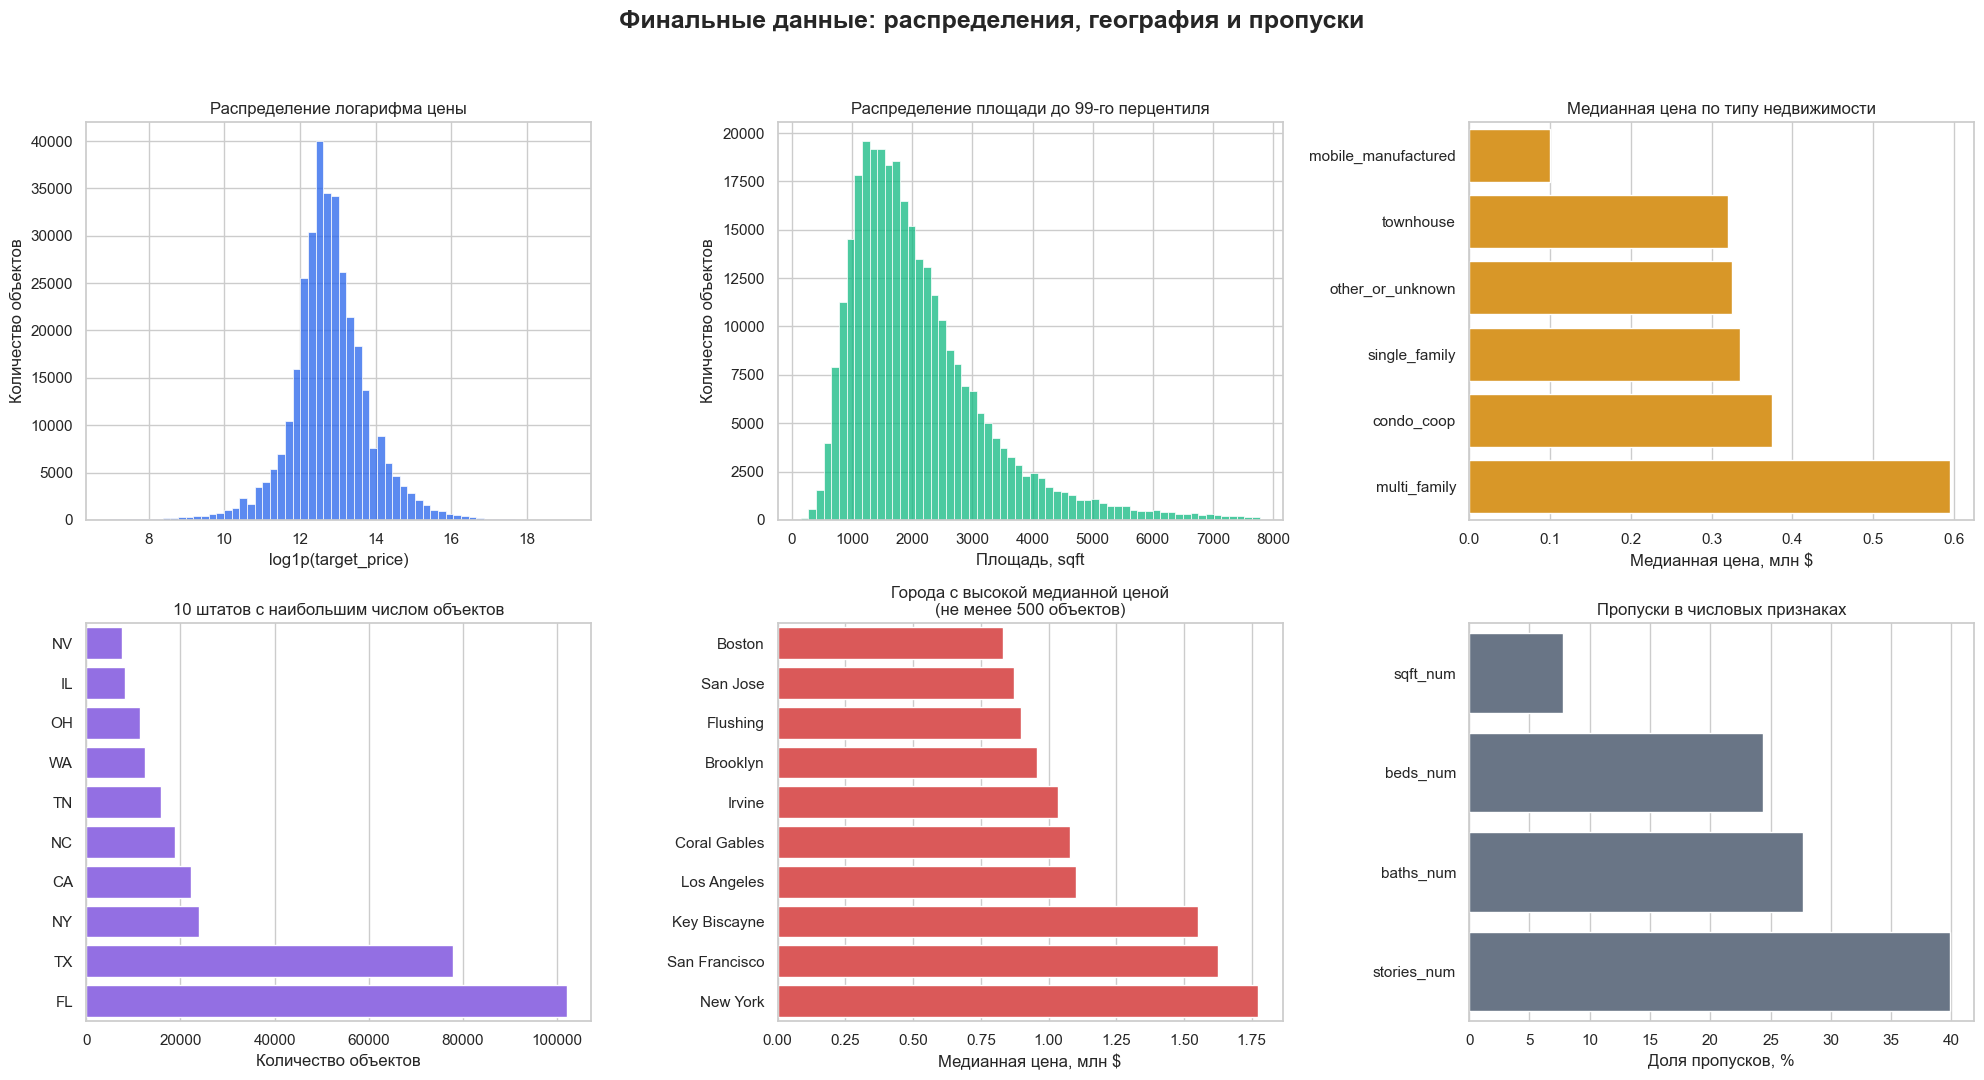

In [71]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
os.makedirs("output", exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle(
    "Финальные данные: распределения, география и пропуски",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

# 1. Распределение логарифма цены
sns.histplot(
    data=houses,
    x="log_target_price",
    bins=60,
    color="#2563eb",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Распределение логарифма цены")
axes[0, 0].set_xlabel("log1p(target_price)")
axes[0, 0].set_ylabel("Количество объектов")

# 2. Распределение площади без верхних 1% выбросов
sqft_99 = houses["sqft_num"].quantile(0.99)

sns.histplot(
    houses.loc[houses["sqft_num"] <= sqft_99, "sqft_num"].dropna(),
    bins=60,
    color="#10b981",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Распределение площади до 99-го перцентиля")
axes[0, 1].set_xlabel("Площадь, sqft")
axes[0, 1].set_ylabel("Количество объектов")

# 3. Медианная цена по типу объекта
median_price_by_type = (
    houses.groupby("property_type_group")["target_price"]
    .median()
    .sort_values()
)

sns.barplot(
    x=median_price_by_type.values / 1_000_000,
    y=median_price_by_type.index,
    color="#f59e0b",
    ax=axes[0, 2]
)
axes[0, 2].set_title("Медианная цена по типу недвижимости")
axes[0, 2].set_xlabel("Медианная цена, млн $")
axes[0, 2].set_ylabel("")

# 4. Штаты с наибольшим числом объектов
top_states = (
    houses["state_clean"]
    .value_counts()
    .head(10)
    .sort_values()
)

sns.barplot(
    x=top_states.values,
    y=top_states.index,
    color="#8b5cf6",
    ax=axes[1, 0]
)
axes[1, 0].set_title("10 штатов с наибольшим числом объектов")
axes[1, 0].set_xlabel("Количество объектов")
axes[1, 0].set_ylabel("")

# 5. Дорогие города с достаточным числом объявлений
top_cities_by_price = (
    houses.groupby("city_model")
    .agg(
        objects=("target_price", "size"),
        median_price=("target_price", "median")
    )
    .query("objects >= 500")
    .sort_values("median_price", ascending=False)
    .head(10)
    .sort_values("median_price")
)

sns.barplot(
    x=top_cities_by_price["median_price"] / 1_000_000,
    y=top_cities_by_price.index,
    color="#ef4444",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Города с высокой медианной ценой\n(не менее 500 объектов)")
axes[1, 1].set_xlabel("Медианная цена, млн $")
axes[1, 1].set_ylabel("")

# 6. Пропуски в числовых признаках
missing_share = (
    houses[
        ["beds_num", "baths_num", "sqft_num", "stories_num"]
    ]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

sns.barplot(
    x=missing_share.values,
    y=missing_share.index,
    color="#64748b",
    ax=axes[1, 2]
)
axes[1, 2].set_title("Пропуски в числовых признаках")
axes[1, 2].set_xlabel("Доля пропусков, %")
axes[1, 2].set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "output/final_data_overview.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

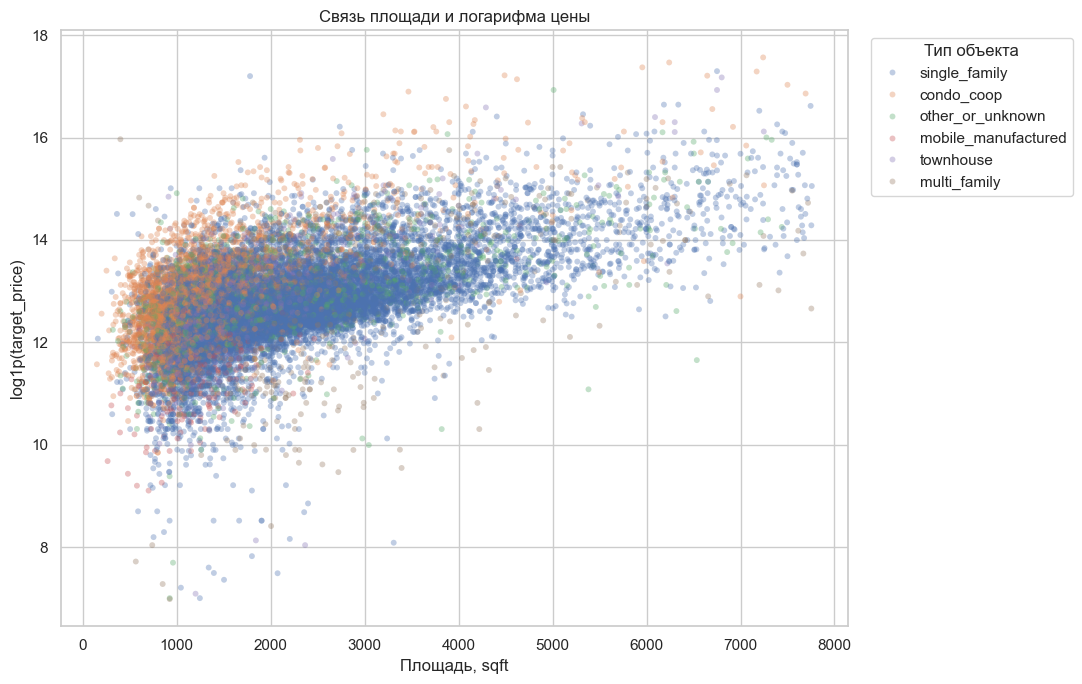

In [72]:
plot_sample = (
    houses[
        houses["sqft_num"].notna()
        & houses["target_price"].notna()
        & (houses["sqft_num"] <= houses["sqft_num"].quantile(0.99))
    ]
    .sample(n=min(20_000, houses["sqft_num"].notna().sum()), random_state=42)
)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=plot_sample,
    x="sqft_num",
    y="log_target_price",
    hue="property_type_group",
    alpha=0.35,
    s=18,
    linewidth=0
)

plt.title("Связь площади и логарифма цены")
plt.xlabel("Площадь, sqft")
plt.ylabel("log1p(target_price)")
plt.legend(
    title="Тип объекта",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [73]:
print("Размер финального датасета:", houses.shape)

display(
    houses[
        [
            "target_price",
            "beds_num",
            "baths_num",
            "sqft_num",
            "stories_num"
        ]
    ].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

display(
    houses.groupby("property_type_group")
    .agg(
        objects=("target_price", "size"),
        median_price=("target_price", "median"),
        median_sqft=("sqft_num", "median"),
        median_beds=("beds_num", "median"),
        median_baths=("baths_num", "median")
    )
    .sort_values("objects", ascending=False)
)

Размер финального датасета: (341954, 43)


,target_price,beds_num,baths_num,sqft_num,stories_num
count,341954.0,258590.0,247175.0,315275.0,205562.0
mean,676980.43321,3.37158,2.785548,2185.998202,2.018471
std,1879766.590618,1.413586,1.324263,1479.896854,2.925147
min,1050.0,1.0,0.75,150.0,1.0
1%,20000.0,1.0,1.0,575.74,1.0
5%,72500.0,2.0,1.0,802.0,1.0
25%,209990.0,3.0,2.0,1300.0,1.0
50%,339900.0,3.0,2.5,1840.0,2.0
75%,599900.0,4.0,3.0,2614.0,2.0
95%,1998175.0,5.0,5.0,4615.3,4.0


,objects,median_price,median_sqft,median_beds,median_baths
property_type_group,,,,,
single_family,205005,334900.0,2059.0,3.0,2.5
condo_coop,57051,375000.0,1189.0,2.0,2.0
other_or_unknown,45495,325000.0,1777.0,3.0,3.0
townhouse,18511,319900.0,1647.0,3.0,3.0
multi_family,12331,595000.0,2323.5,5.0,3.0
mobile_manufactured,3561,99500.0,1280.0,3.0,2.0


Финальные визуализации подтверждают результаты очистки и подготовки признаков.

Распределение `log_target_price` стало значительно ближе к симметричному по сравнению с исходной ценой, поэтому данный признак подходит в качестве целевой переменной для регрессионных моделей.

Площадь объектов имеет правостороннюю асимметрию, однако основная часть наблюдений сосредоточена примерно в диапазоне от 800 до 3 000 sqft. Между площадью и логарифмом цены наблюдается положительная связь: более крупные объекты в среднем стоят дороже. Одновременно заметный разброс цен при одинаковой площади показывает, что для прогнозирования важны также география, тип недвижимости и статус объявления.

Наиболее высокую медианную цену имеет категория `multi_family` — около 595 тыс. долларов. Категория `mobile_manufactured` является наиболее доступной, с медианной ценой около 99.5 тыс. долларов.

Наибольшее количество объектов расположено во Флориде и Техасе. Среди городов с достаточным числом объявлений наиболее высокие медианные цены наблюдаются в Нью-Йорке, Сан-Франциско и Ки-Бискейн.

Наиболее высокая доля пропусков сохраняется у `stories_num`, поэтому при моделировании необходимы медианная иммутация и индикатор `stories_missing`. Индикаторы пропусков для количества спален, ванных комнат, площади и этажности должны быть сохранены в наборе признаков.